# DS-MFG QUBO with QiskitOpt.jl

This notebook is a worked case study for solving the DS-MFG discrete integer-programming QUBO with local classical emulations of QAOA and VQE through `QiskitOpt.jl` and Qiskit Aer.

The original Gurobi model is a 19-variable binary flow problem. The exported QUBO has 36 binary variables: 19 original flow bits followed by 17 auxiliary/slack bits introduced by the QUBO reformulation. The goal is not only to run the algorithms, but to compare their sampled solution distributions against the Gurobi solution pool after accounting for that flow/auxiliary split.

For a manuscript-ready formulation of the problem, the auxiliary reduction, and the final result tables, see `MANUSCRIPT_FINDINGS.tex`.


## Reader Guide

This notebook is organized as a reproducible case-study record rather than an introductory tutorial:

1. Load the exported QUBO and the Gurobi solution pool.
2. Establish the 36-bit QUBO convention: 19 original flow bits plus 17 auxiliary/slack bits.
3. Run small baseline local QAOA/VQE simulations to verify the `QiskitOpt.jl` interface and Aer setup.
4. Compare sampled distributions against Gurobi using both raw 36-bit QUBO states and exact auxiliary repair.
5. Review the QAOA improvement path: fixed-angle starts, final-sampling separation, reduced 19-flow surrogate construction, JuliQAOA statevector angle search, and transferred-angle Aer sampling.
6. Review the VQE improvement path: final-sampling separation, multiple random starts, reduced-surrogate sampling, and high-read follow-up runs.
7. Record disabled hardware-run placeholders for the best local QAOA and VQE configurations.

The central modeling point is that a sampled 36-bit QUBO state can project to a valid Gurobi-pool flow while still carrying a poor auxiliary assignment and therefore a poor raw QUBO energy. The repair analysis fixes the flow bits and chooses the best auxiliary completion, which is the meaningful comparison to the IP objective.


## Files And Outputs

Required input data:

- `Fw_ DS mfg case qubo information.zip`: contains the QUBO CSV files and the Gurobi pool JSON.
- `scalars.csv`, `L_vector.csv`, `Q_matrix.csv`: define the 36-variable QUBO as `scale * (L'x + x'Qx + offset)`.
- `gurobi_pool_solutions_n36_*.json`: contains the Gurobi pool over the 19 original flow variables.

Companion documents:

- `README_STUDENT.md`: bundle-level guide and rerun instructions.
- `MANUSCRIPT_FINDINGS.tex`: manuscript-ready problem statement, reduction, result tables, and hardware placeholders.
- `MANUSCRIPT_FINDINGS.md`: compact narrative summary.

Important generated output folders:

- `ds_mfg_saved_distributions`: baseline QAOA/VQE distributions.
- `ds_mfg_fixed_angle_sweep`: QAOA fixed-angle p=1..5 results.
- `ds_mfg_aux_repair_analysis`: exact auxiliary-repair summaries over saved distributions.
- `ds_mfg_final_sampling_sweep_v2`: best full-QUBO QAOA final-sampling result.
- `ds_mfg_reduced_flow_objective`: exact reduced 19-flow objective and QAOA-on-surrogate result.
- `ds_mfg_qaoa_juliqaoa_angle_search`: original JuliQAOA statevector angle search on the reduced surrogate.
- `ds_mfg_qaoa_juliqaoa_transfer`: QiskitOpt/Aer QAOA sampling with transferred JuliQAOA angles.
- `ds_mfg_qaoa_juliqaoa_transfer_highread`: high-read QiskitOpt/Aer QAOA follow-up for the best transferred angles.
- `ds_mfg_vqe_final_sampling_sweep_v2`: 5-seed full-QUBO VQE sweep.
- `ds_mfg_vqe_reduced_flow_objective_v2`: 5-seed reduced-surrogate VQE sweep.
- `ds_mfg_vqe_reduced_flow_objective_v3`: 20-seed reduced-surrogate VQE top-50/global-hit sweep with `QiskitOpt v0.4.1`.
- `ds_mfg_vqe_reduced_flow_objective_v4`: high-read follow-up on the best reduced-surrogate VQE seeds.
- `ds_mfg_vqe_reduced_flow_objective_final`: final VQE follow-up cache, if present.

Figures are written as SVGs in this analysis bundle so they can be opened without running Julia.


## How To Reproduce

From this analysis bundle, the notebook can be run interactively in Jupyter with the `QiskitOpt Julia` kernel. For a full non-interactive execution, use:

```bash
scripts/nbconvert_ds_mfg.sh
```

That helper creates a project-local IJulia kernel using the Julia executable selected by `JULIA_BIN` or `PATH`. Julia 1.10 or newer is recommended. The `--compiled-modules=no` setting is intentional: in this environment it avoids a ZMQ precompile abort that otherwise prevents IJulia from starting.

The helper's kernel environment includes both `IJulia` and `PythonCall`, and the packaged project also includes `IJulia` as a notebook dependency. This is intentional. When the notebook activates this folder's project and then loads `PythonCall`, Julia may load IJulia's `IJuliaPythonCallExt` package extension from the active project manifest. If these dependencies are not recorded there, Julia can print an extension-loading error even after the project itself has been instantiated. The project depends on the registered `QiskitOpt v0.4.1` release from Julia's General registry; no local package source checkout is required.

Several long-running experiment cells are written to use cached CSVs. If the cached result files are present, the notebook reports them instead of rerunning the quantum simulation.


## Main Results At A Glance

Gurobi global optimum:

- IP/QUBO repaired objective: `11.7095`
- flow bitstring: `1001110100111100011`

QAOA results currently cached:

- Full QAOA with separate final sampling: repaired Gurobi-pool objective `14.5505`.
- Reduced-surrogate QAOA with fixed-angle warm starts: no Gurobi-pool sample in the cached 512 final reads.
- Reduced-surrogate QAOA with JuliQAOA-learned p=5 angles and 262144 final reads: sampled the Gurobi global optimum 664 times. This is the strongest cached quantum-emulation result in the bundle and it remains the accepted QAOA endpoint.

VQE results currently cached:

- Full VQE, 5 seeds with 8192 final reads: repaired Gurobi-pool objective `14.6515`.
- Reduced-surrogate VQE, 5 seeds with 8192 final reads: repaired Gurobi-pool objective `11.8105`.
- Reduced-surrogate VQE, 20 seeds with 32768 final reads: sampled the Gurobi global optimum 3 times.
- Reduced-surrogate VQE, high-read follow-up on 3 selected seeds with 262144 final reads: sampled the Gurobi global optimum 19 times.
- Final reduced-surrogate VQE follow-up on the same 3 selected seeds with 524288 final reads each: sampled the Gurobi global optimum 28 times total, with seed 74018 producing 20 of those reads.

The main practical improvement is the reduced 19-flow surrogate plus exact auxiliary repair. With `QiskitOpt v0.4.1`, local Aer MPS backend options are set through public optimizer attributes. JuliQAOA can then be used as an offline statevector angle finder, and those angles transfer cleanly back into QiskitOpt/Aer QAOA sampling. The later VQE follow-up also reaches the optimum, but at much lower frequency than the p=5 transferred-angle QAOA run.


## Caveats For Interpretation

All quantum algorithm results here are local Aer simulations, not hardware runs. The QAOA fixed-angle initializations come from a regular MaxCut heuristic and are only used as warm starts; this DS-MFG QUBO is not a regular MaxCut instance. The reduced 19-flow objective is exact after auxiliary elimination, but the QAOA/VQE interface accepts a quadratic QUBO, so the notebook fits a quadratic surrogate to that exact reduced objective before running QAOA/VQE.

When judging a result, use the exact repaired objective and the Gurobi-pool match columns, not only the raw sampled QUBO energy.


In [1]:
import Pkg

# The notebook is packaged as a normal Julia project.  Activate the folder
# containing this notebook, then instantiate the registered dependencies.
PROJECT_ROOT = @__DIR__
REPO_ROOT = PROJECT_ROOT  # Existing analysis cells use this name for artifact paths.

isfile(joinpath(PROJECT_ROOT, "Project.toml")) || error("Could not find Project.toml next to this notebook")
Pkg.activate(PROJECT_ROOT)
Pkg.instantiate()

using Dates
using DelimitedFiles
using LinearAlgebra
using Printf
using PythonCall
using Random

using QiskitOpt
using QiskitOpt: QAOA, VQE
using QUBO
using QUBODrivers
using QUBOTools

MOI = QUBODrivers.MOI
SampleReads = QUBOTools.__moi_num_reads()
BASELINE_RANDOM_SEED = 20260611
Random.seed!(BASELINE_RANDOM_SEED)

println("Using notebook project: ", PROJECT_ROOT)
println("Using QiskitOpt.jl v", pkgversion(QiskitOpt), " from: ", pkgdir(QiskitOpt))


  Activating project at `~/repos/QiskitOpt.jl/ds_mfg_student_package_20260605`


    CondaPkg Found dependencies: /home/bernalde/repos/QiskitOpt.jl/ds_mfg_student_package_20260605/CondaPkg.toml


    CondaPkg Found dependencies: /home/bernalde/.julia/packages/PythonCall/5WGSP/CondaPkg.toml


    CondaPkg Found dependencies: /home/bernalde/.julia/packages/QiskitOpt/K2r9R/CondaPkg.toml


    CondaPkg Found dependencies: /home/bernalde/.julia/packages/CondaPkg/lKlVY/CondaPkg.toml


...

 WARN Skipping file for psutil: psutil-2.1.2.win-amd64-py2.7.exe
 WARN Skipping file for psutil: psutil-2.1.2.win-amd64-py3.3.exe
 WARN Skipping file for psutil: psutil-2.1.2.win-amd64-py3.4.exe
 WARN Skipping file for psutil: psutil-2.1.2.win32-py2.4.exe
 WARN Skipping file for psutil: psutil-2.1.2.win32-py2.5.exe
 WARN Skipping file for psutil: psutil-2.1.2.win32-py2.6.exe
 WARN Skipping file for psutil: psutil-2.1.2.win32-py2.7.exe
 WARN Skipping file for psutil: psutil-2.1.2.win32-py3.3.exe
 WARN Skipping file for psutil: psutil-2.1.2.win32-py3.4.exe
 WARN Skipping file for psutil: psutil-2.1.3.win-amd64-py2.7.exe
 WARN Skipping file for psutil: psutil-2.1.3.win-amd64-py3.3.exe
 WARN Skipping file for psutil: psutil-2.1.3.win-amd64-py3.4.exe
 WARN Skipping file for psutil: psutil-2.1.3.win32-py2.4.exe
 WARN Skipping file for psutil: psutil-2.1.3.win32-py2.5.exe
 WARN Skipping file for psutil: psutil-2.1.3.win32-py2.6.exe
 WARN Skipping file for psutil: psutil-2.1.3.win32-py2.7.exe


 WARN Skipping file for requests: requests-2.23.0-py2.7.egg
 WARN Skipping file for dill: dill-0.2a1.win32.exe
 WARN Skipping file for dill: dill-0.2b1.win32.exe
 WARN Skipping file for networkx: networkx-0.34-py2.4.egg
 WARN Skipping file for networkx: networkx-0.34-py2.5.egg
 WARN Skipping file for networkx: networkx-0.34.win32.exe
 WARN Skipping file for networkx: networkx-0.35-py2.4.egg
 WARN Skipping file for networkx: networkx-0.35-py2.5.egg
 WARN Skipping file for networkx: networkx-0.35.1-py2.4.egg
 WARN Skipping file for networkx: networkx-0.35.1-py2.5.egg
 WARN Skipping file for networkx: networkx-0.35.1.win32.exe
 WARN Skipping file for networkx: networkx-0.35.win32.exe
 WARN Skipping file for networkx: networkx-0.36-py2.4.egg
 WARN Skipping file for networkx: networkx-0.36-py2.5.egg
 WARN Skipping file for networkx: networkx-0.36.win32.exe
 WARN Skipping file for networkx: networkx-0.37-py2.4.egg
 WARN Skipping file for networkx: networkx-0.37-py2.5.egg
 WARN Skipping file 

 WARN Skipping file for pyjwt: PyJWT-0.1.1-py2.5.egg
 WARN Skipping file for pyjwt: PyJWT-0.1.1-py2.6.egg
 WARN Skipping file for pyjwt: PyJWT-0.1.1-py2.7.egg
 WARN Skipping file for pyjwt: PyJWT-0.1.2-py2.5.egg
 WARN Skipping file for pyjwt: PyJWT-0.1.2-py2.6.egg
 WARN Skipping file for pyjwt: PyJWT-0.1.2-py2.7.egg
 WARN Skipping file for pyjwt: PyJWT-0.1.3-py2.5.egg
 WARN Skipping file for pyjwt: PyJWT-0.1.3-py2.6.egg
 WARN Skipping file for pyjwt: PyJWT-0.1.3-py2.7.egg
 WARN Skipping file for pyjwt: PyJWT-0.1.4-py2.5.egg
 WARN Skipping file for pyjwt: PyJWT-0.1.4-py2.6.egg
 WARN Skipping file for pyjwt: PyJWT-0.1.4-py2.7.egg
 WARN Skipping file for pyjwt: PyJWT-0.1.5-py2.5.egg
 WARN Skipping file for pyjwt: PyJWT-0.1.5-py2.6.egg
 WARN Skipping file for pyjwt: PyJWT-0.1.5-py2.7.egg
 WARN Skipping file for pyjwt: PyJWT-0.1.6-py2.5.egg
 WARN Skipping file for pyjwt: PyJWT-0.1.6-py2.6.egg
 WARN Skipping file for pyjwt: PyJWT-0.1.6-py2.7.egg
 WARN Skipping file for pyjwt: PyJWT-0.1.7-py2

✔ The default environment has been installed.


Using notebook project: /home/bernalde/repos/QiskitOpt.jl/ds_mfg_student_package_20260605
Using QiskitOpt.jl v0.4.1 from: /home/bernalde/.julia/packages/QiskitOpt/K2r9R


## Load The Exported QUBO

The loader first looks for extracted CSV/JSON files in the notebook directory, this analysis bundle, `julia_exports`, and `result_gurobi`. If they are not present, it extracts the local zip archive `Fw_ DS mfg case qubo information.zip` into a temporary directory and reads the files from there.


### Data Convention: Flow Bits And Auxiliary Bits

The exported QUBO has 36 binary variables. The first 19 variables are the original flow/decision variables from the IP model. The remaining 17 variables are auxiliary/slack bits introduced by the QUBO reformulation. The Gurobi pool only identifies the 19 flow bits, so most comparisons in this notebook track both the 19-bit projection and the full 36-bit encoded state.


In [2]:
function unique_paths(paths)
    out = String[]
    for path in paths
        resolved = abspath(path)
        resolved in out || push!(out, resolved)
    end
    return out
end

function first_existing_file(dir, names)
    for name in names
        path = joinpath(dir, name)
        isfile(path) && return path
    end
    return nothing
end

function first_matching_gurobi_json(dirs)
    for dir in unique_paths(dirs)
        isdir(dir) || continue
        files = readdir(dir)
        preferred = sort(filter(name -> startswith(name, "gurobi_pool_solutions_n36") && endswith(name, ".json"), files))
        isempty(preferred) || return joinpath(dir, first(preferred))
        matches = sort(filter(name -> startswith(name, "gurobi_pool_solutions") && endswith(name, ".json"), files))
        isempty(matches) || return joinpath(dir, first(matches))
    end
    return nothing
end

function find_qubo_csvs(dirs)
    scalar_names = ("scalars.csv", "scalar_csv", "scalar_csv.csv", "scalar.csv")
    for dir in unique_paths(dirs)
        isdir(dir) || continue
        scalars = first_existing_file(dir, scalar_names)
        l_vector = joinpath(dir, "L_vector.csv")
        q_matrix = joinpath(dir, "Q_matrix.csv")
        if !isnothing(scalars) && isfile(l_vector) && isfile(q_matrix)
            return (scalars=scalars, l_vector=l_vector, q_matrix=q_matrix)
        end
    end
    return nothing
end

function materialize_input_files()
    base_dirs = [
        pwd(),
        REPO_ROOT,
        joinpath(pwd(), "julia_exports"),
        joinpath(REPO_ROOT, "julia_exports"),
    ]
    result_dirs = [
        pwd(),
        REPO_ROOT,
        joinpath(pwd(), "result_gurobi"),
        joinpath(REPO_ROOT, "result_gurobi"),
    ]

    qubo = find_qubo_csvs(base_dirs)
    gurobi_json = first_matching_gurobi_json(result_dirs)
    if !isnothing(qubo) && !isnothing(gurobi_json)
        return merge(qubo, (gurobi_json=gurobi_json, source="filesystem"))
    end

    zip_name = "Fw_ DS mfg case qubo information.zip"
    zip_candidates = filter(isfile, [joinpath(pwd(), zip_name), joinpath(REPO_ROOT, zip_name)])
    zip_path = isempty(zip_candidates) ? nothing : first(zip_candidates)
    isnothing(zip_path) && error("Could not find extracted QUBO files or $(zip_name)")

    extract_dir = mktempdir(; prefix="ds_mfg_qubo_")
    run(`unzip -q -o $zip_path -d $extract_dir`)
    qubo = find_qubo_csvs([extract_dir, joinpath(extract_dir, "julia_exports")])
    gurobi_json = first_matching_gurobi_json([extract_dir, joinpath(extract_dir, "result_gurobi")])
    if isnothing(qubo) || isnothing(gurobi_json)
        error("The archive was found, but the expected CSV/JSON files were not all present after extraction")
    end
    return merge(qubo, (gurobi_json=gurobi_json, source=zip_path))
end

function maybe_float(cell)
    cell isa Number && return Float64(cell)
    text = strip(String(cell))
    isempty(text) && return nothing
    return tryparse(Float64, text)
end

function parse_scalars(path)
    raw = readdlm(path, ',', Any)
    for i in 1:size(raw, 1)
        parsed = [maybe_float(raw[i, j]) for j in 1:size(raw, 2)]
        if length(parsed) >= 3 && all(!isnothing, parsed[1:3])
            n = round(Int, parsed[1])
            return (n=n, scale=Float64(parsed[2]), offset=Float64(parsed[3]))
        end
    end
    error("Could not parse n, scale, and offset from $(path)")
end

paths = materialize_input_files()
scalars = parse_scalars(paths.scalars)
L = vec(readdlm(paths.l_vector, ',', Float64))
Q = Matrix{Float64}(readdlm(paths.q_matrix, ',', Float64))

@assert scalars.n == length(L) == size(Q, 1) == size(Q, 2)

println("Data source: ", paths.source)
println("QUBO dimension: ", scalars.n)
println("scale = ", scalars.scale, ", offset = ", scalars.offset)
println("nonzero linear terms: ", count(!iszero, L))
println("nonzero quadratic terms: ", count(!iszero, Q))


Data source: /home/bernalde/repos/QiskitOpt.jl/ds_mfg_student_package_20260605/Fw_ DS mfg case qubo information.zip
QUBO dimension: 36
scale = 1.0, offset = 601.4761999999997
nonzero linear terms: 35
nonzero quadratic terms: 101


In [3]:
bits_signature(bits) = join(string.(Int.(bits)))

function flow_value(values, flow_name)
    for key in ("f($(flow_name))", flow_name)
        try
            return pyconvert(Float64, values[key])
        catch
        end
    end
    error("Could not find flow $(flow_name) in Gurobi solution values")
end

function load_gurobi_pool(path; n_flows=19)
    json = pyimport("json")
    builtins = pyimport("builtins")
    data = json.load(builtins.open(path, "r"))
    flow_names = ["f$(lpad(string(i), 2, '0'))" for i in 0:(n_flows - 1)]

    solutions = NamedTuple[]
    for sol in data["solutions"]
        values = sol["values"]
        bits = [round(Int, flow_value(values, name)) for name in flow_names]
        push!(solutions, (
            solution_id = pyconvert(Int, sol["solution_id"]),
            ip_obj_value = pyconvert(Float64, sol["ip_obj_value"]),
            bits = bits,
            signature = bits_signature(bits),
        ))
    end

    best = minimum(solution.ip_obj_value for solution in solutions)
    global_optima = filter(solution -> isapprox(solution.ip_obj_value, best; atol=1e-8), solutions)
    optimum_signatures = Set(solution.signature for solution in global_optima)
    pool_objective_by_signature = Dict(solution.signature => solution.ip_obj_value for solution in solutions)

    return (
        path = path,
        flow_names = flow_names,
        solutions = solutions,
        best_objective = best,
        global_optima = global_optima,
        optimum_signatures = optimum_signatures,
        pool_objective_by_signature = pool_objective_by_signature,
    )
end

gurobi = load_gurobi_pool(paths.gurobi_json; n_flows=19)
println("Gurobi pool JSON: ", gurobi.path)
println("Gurobi solutions in pool: ", length(gurobi.solutions))
@printf("Gurobi global optimum objective: %.4f\n", gurobi.best_objective)
println("Projected global optimum flow bitstring(s):")
for solution in gurobi.global_optima
    println("  id=", solution.solution_id, " bits=", solution.signature)
end


Gurobi pool JSON: /tmp/ds_mfg_qubo_uaQEIa/gurobi_pool_solutions_n36_20260126_105706.json
Gurobi solutions in pool: 36
Gurobi global optimum objective: 11.7095
Projected global optimum flow bitstring(s):
  id=1 bits=1001110100111100011


## Build And Solve The QUBO

This cell solves the same QUBO with both `QAOA.Optimizer` and `VQE.Optimizer`. With no IBM backend selected, QiskitOpt.jl uses local Aer simulation by default. The defaults are intentionally small so the 36-variable local emulation finishes quickly; increase `number_of_reads` and `maximum_iterations` for a more robust distribution.

The `use_fast_aer_backend` option below makes Aer's matrix-product-state simulation approximate: it uses single precision, multiple MPS threads, a looser truncation threshold, and a capped MPS bond dimension. Set it to `false`, or set `fast_mps_max_bond_dimension = nothing` and `fast_mps_truncation_threshold = 1e-16`, for a more faithful but slower local simulation.


### Baseline Solver Settings

The first QAOA/VQE solve is intentionally small. It verifies that the package can build the QUBO and that local Aer sampling works. Later sections use cached sweeps with more carefully chosen parameters and larger final-sampling counts.


In [4]:
function build_qubo_model(optimizer_factory, L, Q; scale=1.0, offset=0.0)
    model = MOI.instantiate(optimizer_factory; with_cache_type=Float64)
    n = length(L)
    x = MOI.add_variables(model, n)
    for variable in x
        MOI.add_constraint(model, variable, MOI.ZeroOne())
    end

    quadratic_terms = MOI.ScalarQuadraticTerm{Float64}[]
    for i in 1:n, j in 1:n
        coefficient = scale * Q[i, j]
        iszero(coefficient) && continue
        push!(quadratic_terms, MOI.ScalarQuadraticTerm(i == j ? 2coefficient : coefficient, x[i], x[j]))
    end

    linear_terms = MOI.ScalarAffineTerm{Float64}[]
    for i in 1:n
        coefficient = scale * L[i]
        iszero(coefficient) && continue
        push!(linear_terms, MOI.ScalarAffineTerm(coefficient, x[i]))
    end

    objective = MOI.ScalarQuadraticFunction(quadratic_terms, linear_terms, scale * offset)
    MOI.set(model, MOI.ObjectiveSense(), MOI.MIN_SENSE)
    MOI.set(model, MOI.ObjectiveFunction{typeof(objective)}(), objective)
    return model, x
end

use_fast_aer_backend = true
fast_aer_threads = parse(Int, get(ENV, "DSMFG_FAST_AER_THREADS", "8"))
fast_aer_precision = "single"
fast_mps_truncation_threshold = 1e-10
fast_mps_max_bond_dimension = 64
baseline_algorithm_seeds = Dict(:QAOA => BASELINE_RANDOM_SEED + 1, :VQE => BASELINE_RANDOM_SEED + 2)

function configured_local_backend(; seed=nothing)
    if !use_fast_aer_backend
        return QiskitOpt.default_local_backend()
    end

    kwargs = Dict{Symbol,Any}(
        :method => "matrix_product_state",
        :precision => fast_aer_precision,
        :max_parallel_threads => fast_aer_threads,
        :mps_omp_threads => fast_aer_threads,
        :matrix_product_state_truncation_threshold => fast_mps_truncation_threshold,
        :mps_sample_measure_algorithm => "mps_heuristic",
    )
    isnothing(seed) || (kwargs[:seed_simulator] = seed)
    if !isnothing(fast_mps_max_bond_dimension)
        kwargs[:matrix_product_state_max_bond_dimension] = fast_mps_max_bond_dimension
    end
    return QiskitOpt.qiskit_aer.AerSimulator(; kwargs...)
end

function deterministic_initial_parameters(algorithm; number_of_layers, n_variables, seed)
    if algorithm == :QAOA
        rng = Random.MersenneTwister(seed)
        return 2 * pi .* rand(rng, 2 * number_of_layers)
    elseif algorithm == :VQE
        return VQE.random_initial_parameters(n_variables = n_variables, seed = seed)
    else
        error("algorithm must be :QAOA or :VQE")
    end
end

function solve_with_qiskitopt(algorithm, L, Q, scale, offset; number_of_reads=256, maximum_iterations=15, number_of_layers=1, initial_parameters=nothing, final_number_of_reads=nothing, seed=nothing)
    solver_module, optimizer_factory = if algorithm == :QAOA
        (QAOA, QAOA.Optimizer)
    elseif algorithm == :VQE
        (VQE, VQE.Optimizer)
    else
        error("algorithm must be :QAOA or :VQE")
    end

    model, x = build_qubo_model(optimizer_factory, L, Q; scale=scale, offset=offset)
    MOI.set(model, solver_module.IBMFakeBackend(), () -> configured_local_backend(seed = seed))
    MOI.set(model, solver_module.MaximumIterations(), maximum_iterations)
    MOI.set(model, solver_module.NumberOfReads(), number_of_reads)
    algorithm == :QAOA && MOI.set(model, QAOA.NumberOfLayers(), number_of_layers)
    if !isnothing(seed)
        MOI.set(model, solver_module.AerSeedSimulator(), seed)
        MOI.set(model, solver_module.TranspilerSeed(), seed)
    end
    if !isnothing(final_number_of_reads)
        MOI.set(model, QUBODrivers.FinalNumberOfReads(), final_number_of_reads)
    end

    parameters = initial_parameters
    if isnothing(parameters) && !isnothing(seed)
        parameters = deterministic_initial_parameters(algorithm; number_of_layers = number_of_layers, n_variables = length(L), seed = seed)
    end
    if !isnothing(parameters)
        parameter_attribute = algorithm == :QAOA ? QAOA.InitialParameters() : VQE.InitialParameters()
        source_attribute = algorithm == :QAOA ? QAOA.InitialParameterSource() : VQE.InitialParameterSource()
        MOI.set(model, parameter_attribute, parameters)
        isnothing(seed) || MOI.set(model, source_attribute, "random_seed_$(seed)")
    end

    MOI.optimize!(model)
    return model, x
end

number_of_reads = 128
maximum_iterations = 10
number_of_layers = 1

println("Aer backend: ", use_fast_aer_backend ? "fast approximate MPS" : "default MPS")
use_fast_aer_backend && println("  precision=", fast_aer_precision, ", threads=", fast_aer_threads, ", truncation=", fast_mps_truncation_threshold, ", max_bond_dimension=", fast_mps_max_bond_dimension)

algorithm_results = Dict{Symbol,NamedTuple}()
for algorithm in (:QAOA, :VQE)
    seed = baseline_algorithm_seeds[algorithm]
    println("Solving with ", algorithm, "...")
    println("  Seed: ", seed)
    model, x = solve_with_qiskitopt(
        algorithm,
        L,
        Q,
        scalars.scale,
        scalars.offset;
        number_of_reads = number_of_reads,
        maximum_iterations = maximum_iterations,
        number_of_layers = number_of_layers,
        seed = seed,
    )

    algorithm_results[algorithm] = (model=model, x=x)
    println("  Termination status: ", MOI.get(model, MOI.TerminationStatus()))
    println("  Unique sampled states: ", MOI.get(model, MOI.ResultCount()))
    @printf("  Solve time: %.3f seconds\n", MOI.get(model, MOI.SolveTimeSec()))
end

Aer backend: fast approximate MPS
  precision=

single, threads=36, truncation=1.0e-10, max_bond_dimension=64
Solving with QAOA...


  Termination status: LOCALLY_SOLVED
  Unique sampled states: 128
  Solve time: 23.287 seconds
Solving with VQE...
  Termination status: 

LOCALLY_SOLVED
  Unique sampled states: 1
  Solve time: 0.687 seconds


## Compare The Sample Distributions To Gurobi

`match` is now a projection-level label: it compares the first 19 flow bits against the Gurobi pool. `encoded_match` is stricter: it only remains `gurobi_pool` or `global_optimum` when the sampled auxiliary bits are also the minimum-energy QUBO extension for that fixed flow projection. Projection-only hits are labeled, for example, `projection_only_gurobi_pool`, and `qubo_energy_gap_to_best_aux` records the penalty gap to the best auxiliary assignment for that same flow state.

In [5]:
function manual_qubo_energy(bits, L, Q, scale, offset)
    return scale * (dot(L, bits) + dot(bits, Q * bits) + offset)
end

bits_from_signature(signature) = [parse(Int, string(character)) for character in collect(signature)]

function hamming_distance(a, b)
    return sum(x != y for (x, y) in zip(a, b); init=0)
end

function conditional_best_auxiliary(flow_signature, L, Q, scale, offset; n_flows=19)
    fixed_bits = bits_from_signature(flow_signature)
    n = length(L)
    n_aux = n - n_flows
    n_aux < 0 && error("n_flows=$(n_flows) exceeds QUBO dimension $(n)")

    best_energy = Inf
    best_bits = Int[]
    for mask in 0:(2^n_aux - 1)
        aux_bits = digits(mask; base=2, pad=n_aux)
        candidate = vcat(fixed_bits, aux_bits)
        energy = manual_qubo_energy(candidate, L, Q, scale, offset)
        if energy < best_energy
            best_energy = energy
            best_bits = candidate
        end
    end

    best_aux_bits = best_bits[n_flows + 1:end]
    return (
        best_aux_bits = bits_signature(best_aux_bits),
        best_full_bits = bits_signature(best_bits),
        best_qubo_energy = best_energy,
    )
end

function auxiliary_annotation(bits, checked_energy, projection_match, L, Q, scale, offset; n_flows=19, atol=1e-6)
    flow_signature = bits_signature(bits[1:n_flows])
    best_aux = conditional_best_auxiliary(flow_signature, L, Q, scale, offset; n_flows=n_flows)
    sampled_aux_bits = bits_signature(bits[n_flows + 1:end])
    gap = checked_energy - best_aux.best_qubo_energy
    aux_consistent = projection_match == "not_in_gurobi_pool" ? missing : isapprox(gap, 0.0; atol=atol)
    encoded_match = if projection_match == "not_in_gurobi_pool"
        "not_in_gurobi_pool"
    elseif aux_consistent === true
        projection_match
    else
        "projection_only_$(projection_match)"
    end

    return (
        projection_match = projection_match,
        encoded_match = encoded_match,
        aux_consistent = aux_consistent,
        best_aux_bits = best_aux.best_aux_bits,
        best_full_bits_for_projection = best_aux.best_full_bits,
        best_aux_qubo_energy = best_aux.best_qubo_energy,
        qubo_energy_gap_to_best_aux = gap,
        aux_hamming_to_best = hamming_distance(sampled_aux_bits, best_aux.best_aux_bits),
    )
end

function row_encoded_match(row)
    return hasproperty(row, :encoded_match) ? row.encoded_match : row.match
end

function row_aux_consistent(row)
    return hasproperty(row, :aux_consistent) ? row.aux_consistent : missing
end

function summarize_qiskit_distribution(model, x, L, Q, scale, offset, gurobi; n_flows=19)
    result_count = MOI.get(model, MOI.ResultCount())
    total_reads = sum(MOI.get(model, SampleReads(result)) for result in 1:result_count; init=0)
    rows = NamedTuple[]

    for result in 1:result_count
        bits = round.(Int, MOI.get.(model, MOI.VariablePrimal(result), x))
        reads = MOI.get(model, SampleReads(result))
        reported_energy = MOI.get(model, MOI.ObjectiveValue(result))
        checked_energy = manual_qubo_energy(bits, L, Q, scale, offset)
        flow_signature = bits_signature(bits[1:n_flows])
        matched_ip_obj = get(gurobi.pool_objective_by_signature, flow_signature, missing)
        projection_match = if flow_signature in gurobi.optimum_signatures
            "global_optimum"
        elseif !ismissing(matched_ip_obj)
            "gurobi_pool"
        else
            "not_in_gurobi_pool"
        end
        aux = auxiliary_annotation(bits, checked_energy, projection_match, L, Q, scale, offset; n_flows=n_flows)

        push!(rows, (
            result = result,
            reads = reads,
            probability = total_reads == 0 ? 0.0 : reads / total_reads,
            qubo_energy = reported_energy,
            energy_check_abs_error = abs(reported_energy - checked_energy),
            match = projection_match,
            projection_match = aux.projection_match,
            encoded_match = aux.encoded_match,
            aux_consistent = aux.aux_consistent,
            best_aux_bits = aux.best_aux_bits,
            best_full_bits_for_projection = aux.best_full_bits_for_projection,
            best_aux_qubo_energy = aux.best_aux_qubo_energy,
            qubo_energy_gap_to_best_aux = aux.qubo_energy_gap_to_best_aux,
            aux_hamming_to_best = aux.aux_hamming_to_best,
            matched_ip_obj = matched_ip_obj,
            flow_bits = flow_signature,
            full_bits = bits_signature(bits),
        ))
    end

    return sort(rows; by = row -> (-row.reads, row.qubo_energy))
end

function fmt_ip_obj(value)
    return ismissing(value) ? "-" : @sprintf("%.4f", value)
end

function print_distribution_summary(rows, gurobi)
    total_reads = sum(row.reads for row in rows; init=0)
    global_reads = sum(row.reads for row in rows if row.match == "global_optimum"; init=0)
    pool_reads = sum(row.reads for row in rows if row.match != "not_in_gurobi_pool"; init=0)
    encoded_global_reads = sum(row.reads for row in rows if row_encoded_match(row) == "global_optimum"; init=0)
    encoded_pool_reads = sum(row.reads for row in rows if row_encoded_match(row) in ("global_optimum", "gurobi_pool"); init=0)
    max_energy_error = isempty(rows) ? 0.0 : maximum(row.energy_check_abs_error for row in rows)

    println("Total shots: ", total_reads)
    println("Unique sampled states: ", length(rows))
    @printf("Gurobi best IP objective: %.4f (%d optimum projection(s))
", gurobi.best_objective, length(gurobi.global_optima))
    @printf("Projected global-optimum shots: %d / %d (%.2f%%)
", global_reads, total_reads, total_reads == 0 ? 0.0 : 100 * global_reads / total_reads)
    @printf("Projected Gurobi-pool shots: %d / %d (%.2f%%)
", pool_reads, total_reads, total_reads == 0 ? 0.0 : 100 * pool_reads / total_reads)
    @printf("Full-encoded global-optimum shots: %d / %d (%.2f%%)
", encoded_global_reads, total_reads, total_reads == 0 ? 0.0 : 100 * encoded_global_reads / total_reads)
    @printf("Full-encoded Gurobi-pool shots: %d / %d (%.2f%%)
", encoded_pool_reads, total_reads, total_reads == 0 ? 0.0 : 100 * encoded_pool_reads / total_reads)
    @printf("Maximum QUBO energy check error: %.3e
", max_energy_error)

    if !isempty(rows)
        best_row = rows[argmin([row.qubo_energy for row in rows])]
        println("Best sampled QUBO state projection: ", best_row.flow_bits, " (projection=", best_row.match, ", encoded=", row_encoded_match(best_row), ")")
    end
end

function show_distribution(rows; limit=25)
    isempty(rows) && return println("No samples to show")
    println(rpad("result", 8), lpad("reads", 8), lpad("prob", 10), lpad("qubo_energy", 15), lpad("aux_gap", 12), "  ", rpad("projection", 20), "  ", rpad("encoded", 30), "  ", rpad("flow_bits", 21), "ip_obj")
    println(repeat("-", 132))
    for row in rows[1:min(limit, length(rows))]
        aux_gap = hasproperty(row, :qubo_energy_gap_to_best_aux) && !ismissing(row.qubo_energy_gap_to_best_aux) ? @sprintf("%.4f", row.qubo_energy_gap_to_best_aux) : "-"
        print(rpad(string(row.result), 8))
        print(lpad(string(row.reads), 8))
        print(lpad(@sprintf("%.2f%%", 100 * row.probability), 10))
        print(lpad(@sprintf("%.4f", row.qubo_energy), 15))
        print(lpad(aux_gap, 12))
        print("  ", rpad(row.match, 20))
        print("  ", rpad(row_encoded_match(row), 30))
        print("  ", rpad(row.flow_bits, 21))
        println(fmt_ip_obj(row.matched_ip_obj))
    end
end

const MATCH_ORDER = ["global_optimum", "gurobi_pool", "not_in_gurobi_pool"]
const MATCH_LABELS = Dict(
    "global_optimum" => "Global optimum",
    "gurobi_pool" => "Gurobi pool",
    "not_in_gurobi_pool" => "Outside pool",
)
const MATCH_COLORS = Dict(
    "global_optimum" => "#1f9d78",
    "gurobi_pool" => "#4267d6",
    "not_in_gurobi_pool" => "#8a94a6",
)

svg_escape(text) = replace(String(text), "&" => "&amp;", "<" => "&lt;", ">" => "&gt;")

function dominant_category(category_probability)
    best_category = first(MATCH_ORDER)
    best_probability = get(category_probability, best_category, 0.0)
    for category in MATCH_ORDER[2:end]
        probability = get(category_probability, category, 0.0)
        if probability > best_probability
            best_category = category
            best_probability = probability
        end
    end
    return best_category
end

function energy_distribution(rows; digits=6)
    probability_by_energy = Dict{Float64,Float64}()
    category_probability_by_energy = Dict{Float64,Dict{String,Float64}}()
    for row in rows
        energy = round(row.qubo_energy; digits=digits)
        probability_by_energy[energy] = get(probability_by_energy, energy, 0.0) + row.probability
        category_probability = get!(category_probability_by_energy, energy, Dict{String,Float64}())
        category_probability[row.match] = get(category_probability, row.match, 0.0) + row.probability
    end

    points = [
        (
            energy = energy,
            probability = probability_by_energy[energy],
            match = dominant_category(category_probability_by_energy[energy]),
        )
        for energy in keys(probability_by_energy)
    ]
    return sort(points; by = point -> point.energy)
end

function category_distribution(rows)
    return Dict(category => sum(row.probability for row in rows if row.match == category; init=0.0) for category in MATCH_ORDER)
end

function scale_between(value, lo, hi, out_lo, out_hi)
    if isapprox(lo, hi; atol=1e-12)
        return (out_lo + out_hi) / 2
    end
    return out_lo + (value - lo) * (out_hi - out_lo) / (hi - lo)
end

function draw_energy_panel!(parts, label, points, x, y, w, h, energy_min, energy_max, probability_max)
    baseline = y + h
    push!(parts, @sprintf("<text x='%.1f' y='%.1f' font-size='16' font-weight='700'>%s</text>", x, y - 12, svg_escape(label)))
    push!(parts, @sprintf("<line x1='%.1f' y1='%.1f' x2='%.1f' y2='%.1f' stroke='#263238' stroke-width='1'/>", x, baseline, x + w, baseline))
    push!(parts, @sprintf("<line x1='%.1f' y1='%.1f' x2='%.1f' y2='%.1f' stroke='#263238' stroke-width='1'/>", x, y, x, baseline))
    push!(parts, @sprintf("<text x='%.1f' y='%.1f' font-size='11' fill='#475569'>%.1f</text>", x, baseline + 18, energy_min))
    push!(parts, @sprintf("<text x='%.1f' y='%.1f' font-size='11' fill='#475569' text-anchor='end'>%.1f</text>", x + w, baseline + 18, energy_max))
    push!(parts, @sprintf("<text x='%.1f' y='%.1f' font-size='11' fill='#475569' transform='rotate(-90 %.1f %.1f)'>shot probability</text>", x - 38, y + h / 2, x - 38, y + h / 2))

    for point in points
        px = scale_between(point.energy, energy_min, energy_max, x + 8, x + w - 8)
        py = scale_between(point.probability, 0.0, probability_max, baseline, y + 8)
        color = MATCH_COLORS[point.match]
        push!(parts, @sprintf("<line x1='%.1f' y1='%.1f' x2='%.1f' y2='%.1f' stroke='%s' stroke-width='2' opacity='0.75'/>", px, baseline, px, py, color))
        push!(parts, @sprintf("<circle cx='%.1f' cy='%.1f' r='3.2' fill='%s' stroke='white' stroke-width='0.7'/>", px, py, color))
    end
end

function draw_category_panel!(parts, distributions, x, y, w, h)
    algorithms = [:QAOA, :VQE]
    baseline = y + h
    push!(parts, @sprintf("<text x='%.1f' y='%.1f' font-size='16' font-weight='700'>Gurobi projection match probability</text>", x, y - 14))
    push!(parts, @sprintf("<line x1='%.1f' y1='%.1f' x2='%.1f' y2='%.1f' stroke='#263238' stroke-width='1'/>", x, baseline, x + w, baseline))
    push!(parts, @sprintf("<line x1='%.1f' y1='%.1f' x2='%.1f' y2='%.1f' stroke='#263238' stroke-width='1'/>", x, y, x, baseline))

    group_w = w / length(MATCH_ORDER)
    bar_w = min(44.0, group_w / 4)
    for (category_index, category) in enumerate(MATCH_ORDER)
        group_x = x + (category_index - 0.5) * group_w
        for (algorithm_index, algorithm) in enumerate(algorithms)
            mass = get(category_distribution(distributions[algorithm]), category, 0.0)
            bar_h = h * mass
            bx = group_x + (algorithm_index - 1.5) * (bar_w + 8)
            by = baseline - bar_h
            color = algorithm == :QAOA ? "#2563eb" : "#f97316"
            push!(parts, @sprintf("<rect x='%.1f' y='%.1f' width='%.1f' height='%.1f' fill='%s' rx='3'/>", bx, by, bar_w, bar_h, color))
            push!(parts, @sprintf("<text x='%.1f' y='%.1f' font-size='10' text-anchor='middle' fill='#334155'>%.1f%%</text>", bx + bar_w / 2, max(y + 12, by - 5), 100 * mass))
        end
        push!(parts, @sprintf("<text x='%.1f' y='%.1f' font-size='12' text-anchor='middle' fill='#334155'>%s</text>", group_x, baseline + 18, svg_escape(MATCH_LABELS[category])))
    end
    push!(parts, @sprintf("<text x='%.1f' y='%.1f' font-size='11' fill='#475569' transform='rotate(-90 %.1f %.1f)'>probability mass</text>", x - 42, y + h / 2, x - 42, y + h / 2))
end

function distribution_comparison_svg(distributions, gurobi)
    energy_points = Dict(algorithm => energy_distribution(distributions[algorithm]) for algorithm in (:QAOA, :VQE))
    all_points = vcat(values(energy_points)...)
    energy_min = minimum(point.energy for point in all_points)
    energy_max = maximum(point.energy for point in all_points)
    probability_max = max(0.01, maximum(point.probability for point in all_points))

    parts = String[]
    push!(parts, "<svg xmlns='http://www.w3.org/2000/svg' width='980' height='620' viewBox='0 0 980 620'>")
    push!(parts, "<rect width='980' height='620' fill='white'/>")
    push!(parts, "<text x='36' y='38' font-size='22' font-weight='800' fill='#111827'>QAOA vs VQE sampled solution distributions</text>")
    push!(parts, @sprintf("<text x='36' y='62' font-size='13' fill='#475569'>Gurobi best IP objective %.4f; colors in energy panels mark projected flow-state relation to the Gurobi pool.</text>", gurobi.best_objective))

    draw_energy_panel!(parts, "QAOA energy distribution", energy_points[:QAOA], 70, 120, 390, 210, energy_min, energy_max, probability_max)
    draw_energy_panel!(parts, "VQE energy distribution", energy_points[:VQE], 545, 120, 390, 210, energy_min, energy_max, probability_max)
    draw_category_panel!(parts, distributions, 92, 420, 820, 120)

    legend_x = 72
    for (i, category) in enumerate(MATCH_ORDER)
        lx = legend_x + (i - 1) * 180
        push!(parts, @sprintf("<rect x='%.1f' y='570' width='12' height='12' fill='%s' rx='2'/>", lx, MATCH_COLORS[category]))
        push!(parts, @sprintf("<text x='%.1f' y='581' font-size='12' fill='#334155'>%s</text>", lx + 18, svg_escape(MATCH_LABELS[category])))
    end
    push!(parts, "<rect x='645' y='570' width='12' height='12' fill='#2563eb' rx='2'/><text x='663' y='581' font-size='12' fill='#334155'>QAOA category bars</text>")
    push!(parts, "<rect x='800' y='570' width='12' height='12' fill='#f97316' rx='2'/><text x='818' y='581' font-size='12' fill='#334155'>VQE category bars</text>")
    push!(parts, "</svg>")
    return join(parts, "\n")
end

function simple_csv_text(value)
    text = ismissing(value) ? "" : string(value)
    return replace(text, "," => ";", "\n" => " ", "\r" => " ")
end

function write_simple_csv(path, header, rows)
    open(path, "w") do io
        println(io, join(simple_csv_text.(header), ","))
        for row in rows
            println(io, join(simple_csv_text.(row), ","))
        end
    end
    return path
end

function distribution_csv_rows(distributions)
    rows = Vector{Vector{Any}}()
    for algorithm in (:QAOA, :VQE)
        for row in distributions[algorithm]
            push!(rows, Any[
                string(algorithm),
                baseline_algorithm_seeds[algorithm],
                row.result,
                row.reads,
                row.probability,
                row.qubo_energy,
                row.energy_check_abs_error,
                row.match,
                row.projection_match,
                row.encoded_match,
                row.aux_consistent,
                row.best_aux_bits,
                row.best_full_bits_for_projection,
                row.best_aux_qubo_energy,
                row.qubo_energy_gap_to_best_aux,
                row.aux_hamming_to_best,
                row.matched_ip_obj,
                row.flow_bits,
                row.full_bits,
                number_of_reads,
                maximum_iterations,
                number_of_layers,
                use_fast_aer_backend,
                fast_aer_precision,
                fast_aer_threads,
                fast_mps_truncation_threshold,
                fast_mps_max_bond_dimension,
            ])
        end
    end
    return rows
end

function stable_artifact_path(path)
    text = string(path)
    root = abspath(REPO_ROOT)
    absolute = abspath(text)
    relative = relpath(absolute, root)
    startswith(relative, "..") || return relative
    return joinpath("input_archive", basename(text))
end

stable_artifact_source(source) = source == "filesystem" ? "filesystem" : stable_artifact_path(source)

function save_distribution_artifacts(distributions, algorithm_results, gurobi; output_dir=joinpath(REPO_ROOT, "ds_mfg_saved_distributions"))
    mkpath(output_dir)
    header = [
        "algorithm",
        "seed",
        "result",
        "reads",
        "probability",
        "qubo_energy",
        "energy_check_abs_error",
        "match",
        "projection_match",
        "encoded_match",
        "aux_consistent",
        "best_aux_bits",
        "best_full_bits_for_projection",
        "best_aux_qubo_energy",
        "qubo_energy_gap_to_best_aux",
        "aux_hamming_to_best",
        "matched_ip_obj",
        "flow_bits",
        "full_bits",
        "number_of_reads",
        "maximum_iterations",
        "number_of_layers",
        "use_fast_aer_backend",
        "fast_aer_precision",
        "fast_aer_threads",
        "fast_mps_truncation_threshold",
        "fast_mps_max_bond_dimension",
    ]

    combined_path = joinpath(output_dir, "qaoa_vqe_distribution.csv")
    write_simple_csv(combined_path, header, distribution_csv_rows(distributions))

    method_paths = Dict{Symbol,String}()
    for algorithm in (:QAOA, :VQE)
        path = joinpath(output_dir, "$(lowercase(string(algorithm)))_distribution.csv")
        rows = filter(row -> row[1] == string(algorithm), distribution_csv_rows(distributions))
        write_simple_csv(path, header, rows)
        method_paths[algorithm] = path
    end

    metadata_rows = Any[
        ["generated_at", "not_recorded_for_reproducible_artifacts"],
        ["data_source", stable_artifact_source(paths.source)],
        ["scalars_path", stable_artifact_path(paths.scalars)],
        ["l_vector_path", stable_artifact_path(paths.l_vector)],
        ["q_matrix_path", stable_artifact_path(paths.q_matrix)],
        ["gurobi_json", stable_artifact_path(gurobi.path)],
        ["gurobi_best_objective", gurobi.best_objective],
        ["qubo_dimension", scalars.n],
        ["qubo_scale", scalars.scale],
        ["qubo_offset", scalars.offset],
        ["number_of_reads", number_of_reads],
        ["maximum_iterations", maximum_iterations],
        ["number_of_layers", number_of_layers],
        ["use_fast_aer_backend", use_fast_aer_backend],
        ["fast_aer_precision", fast_aer_precision],
        ["fast_aer_threads", fast_aer_threads],
        ["fast_mps_truncation_threshold", fast_mps_truncation_threshold],
        ["fast_mps_max_bond_dimension", fast_mps_max_bond_dimension],
        ["baseline_random_seed", BASELINE_RANDOM_SEED],
        ["QAOA.seed", baseline_algorithm_seeds[:QAOA]],
        ["VQE.seed", baseline_algorithm_seeds[:VQE]],
        ["combined_distribution_csv", stable_artifact_path(combined_path)],
        ["qaoa_distribution_csv", stable_artifact_path(method_paths[:QAOA])],
        ["vqe_distribution_csv", stable_artifact_path(method_paths[:VQE])],
    ]
    for algorithm in (:QAOA, :VQE)
        push!(metadata_rows, ["$(algorithm).solve_time_sec", "not_recorded_for_reproducible_artifacts"])
        push!(metadata_rows, ["$(algorithm).unique_sampled_states", length(distributions[algorithm])])
        push!(metadata_rows, ["$(algorithm).total_reads", sum(row.reads for row in distributions[algorithm]; init=0)])
    end

    metadata_path = joinpath(output_dir, "run_metadata.csv")
    write_simple_csv(metadata_path, ["key", "value"], metadata_rows)

    return (output_dir=output_dir, combined=combined_path, metadata=metadata_path, qaoa=method_paths[:QAOA], vqe=method_paths[:VQE])
end

function parse_saved_float(text)
    isempty(strip(text)) && return missing
    return parse(Float64, text)
end

function parse_saved_int(text)
    isempty(strip(text)) && return missing
    return parse(Int, text)
end

function parse_saved_bool(text)
    normalized = lowercase(strip(text))
    isempty(normalized) && return missing
    normalized in ("true", "1") && return true
    normalized in ("false", "0") && return false
    return missing
end

function read_simple_csv(path)
    lines = readlines(path)
    isempty(lines) && error("Empty CSV file: $(path)")
    header = split(lines[1], ','; keepempty=true)
    rows = [split(line, ','; keepempty=true) for line in lines[2:end] if !isempty(strip(line))]
    return header, rows
end

function saved_column(row, column, name; default="")
    haskey(column, name) || return default
    index = column[name]
    index > length(row) && return default
    return row[index]
end

function load_saved_distributions(path=joinpath(REPO_ROOT, "ds_mfg_saved_distributions", "qaoa_vqe_distribution.csv"))
    header, rows = read_simple_csv(path)
    column = Dict(name => i for (i, name) in enumerate(header))
    loaded = Dict(:QAOA => NamedTuple[], :VQE => NamedTuple[])
    for row in rows
        algorithm = Symbol(row[column["algorithm"]])
        projection_match = saved_column(row, column, "projection_match"; default=row[column["match"]])
        encoded_match = saved_column(row, column, "encoded_match"; default=projection_match)
        matched_ip_obj = parse_saved_float(row[column["matched_ip_obj"]])
        push!(loaded[algorithm], (
            result = parse(Int, row[column["result"]]),
            reads = parse(Int, row[column["reads"]]),
            probability = parse(Float64, row[column["probability"]]),
            qubo_energy = parse(Float64, row[column["qubo_energy"]]),
            energy_check_abs_error = parse(Float64, row[column["energy_check_abs_error"]]),
            match = row[column["match"]],
            projection_match = projection_match,
            encoded_match = encoded_match,
            aux_consistent = parse_saved_bool(saved_column(row, column, "aux_consistent")),
            best_aux_bits = saved_column(row, column, "best_aux_bits"),
            best_full_bits_for_projection = saved_column(row, column, "best_full_bits_for_projection"),
            best_aux_qubo_energy = parse_saved_float(saved_column(row, column, "best_aux_qubo_energy")),
            qubo_energy_gap_to_best_aux = parse_saved_float(saved_column(row, column, "qubo_energy_gap_to_best_aux")),
            aux_hamming_to_best = parse_saved_int(saved_column(row, column, "aux_hamming_to_best")),
            matched_ip_obj = matched_ip_obj,
            flow_bits = row[column["flow_bits"]],
            full_bits = row[column["full_bits"]],
        ))
    end
    return loaded
end


load_saved_distributions (generic function with 2 methods)

## Save Current Run Distributions

Run this cell after the QAOA/VQE solve cell. It summarizes the sampled distributions, writes the comparison figure, and saves distribution CSVs plus run metadata for later replotting.



QAOA distribution summary


Total shots: 128
Unique sampled states: 128


Gurobi best IP objective: 11.7095 (1 optimum projection(s))
Projected global-optimum shots: 0 / 128 (0.00%)


Projected Gurobi-pool shots: 1 / 128 (0.78%)
Full-encoded global-optimum shots: 0 / 128 (0.00%)
Full-encoded Gurobi-pool shots: 0 / 128 (0.00%)
Maximum QUBO energy check error: 4.547e-13


Best sampled QUBO state projection: 1100110110011100011 (projection=gurobi_pool, encoded=projection_only_gurobi_pool)

result     reads      prob    qubo_energy     aux_gap  projection            encoded                         flow_bits            ip_obj
------------------------------------------------------------------------------------------------------------------------------------
1              1     0.78%       441.9399    427.4830  gurobi_pool           projection_only_gurobi_pool     1100110110011100011  14.4569
2              1     0.78%       442.1634    213.7415  not_in_gurobi_pool    not_in_gurobi_pool              1101110010011010011  -
3              1     0.78%       479.9882    256.4898  not_in_gurobi_pool    not_in_gurobi_pool              1010100001000000000  -
4              1     0.78%       567.6578    384.7347  not_in_gurobi_pool    not_in_gurobi_pool              1010010101001010011  -
5              1     0.78%       610.3051    427.4830  not_in_gurobi_pool    

VQE distribution summary
Total shots: 128
Unique sampled states: 1
Gurobi best IP objective: 11.7095 (1 optimum projection(s))
Projected global-optimum shots: 0 / 128 (0.00%)
Projected Gurobi-pool shots: 0 / 128 (0.00%)
Full-encoded global-optimum shots: 0 / 128 (0.00%)
Full-encoded Gurobi-pool shots: 0 / 128 (0.00%)
Maximum QUBO energy check error: 0.000e+00
Best sampled QUBO state projection: 0000000000000000000 (projection=not_in_gurobi_pool, encoded=not_in_gurobi_pool)

result     reads      prob    qubo_energy     aux_gap  projection            encoded                         flow_bits            ip_obj
------------------------------------------------------------------------------------------------------------------------------------
1            128   100.00%       601.4762    470.2313  not_in_gurobi_pool    not_in_gurobi_pool              0000000000000000000  -


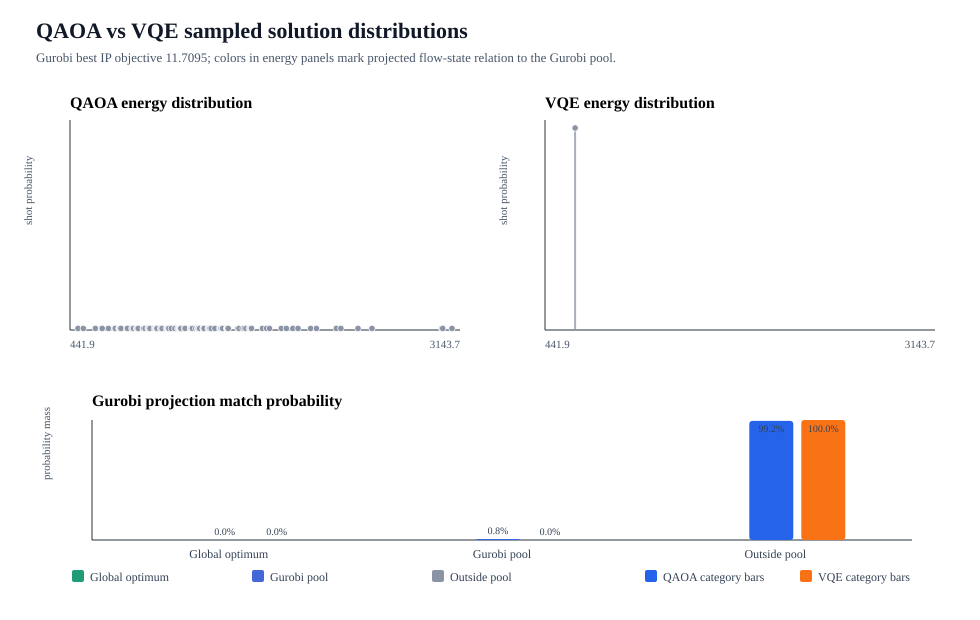


Figure written to: /home/bernalde/repos/QiskitOpt.jl/ds_mfg_student_package_20260605/ds_mfg_qaoa_vqe_distribution.svg
Distribution CSV written to: /home/bernalde/repos/QiskitOpt.jl/ds_mfg_student_package_20260605/ds_mfg_saved_distributions/qaoa_vqe_distribution.csv
Run metadata written to: /home/bernalde/repos/QiskitOpt.jl/ds_mfg_student_package_20260605/ds_mfg_saved_distributions/run_metadata.csv


In [6]:
distributions = Dict{Symbol,Vector{NamedTuple}}()
for algorithm in (:QAOA, :VQE)
    result = algorithm_results[algorithm]
    rows = summarize_qiskit_distribution(result.model, result.x, L, Q, scalars.scale, scalars.offset, gurobi; n_flows=19)
    distributions[algorithm] = rows
    println("\n", algorithm, " distribution summary")
    print_distribution_summary(rows, gurobi)
    println()
    show_distribution(rows; limit=15)
end

figure_svg = distribution_comparison_svg(distributions, gurobi)
figure_path = joinpath(REPO_ROOT, "ds_mfg_qaoa_vqe_distribution.svg")
write(figure_path, figure_svg)
saved_distribution_paths = save_distribution_artifacts(distributions, algorithm_results, gurobi)
try
    display("image/svg+xml", figure_svg)
catch err
    println("Inline SVG display is available in Jupyter/IJulia; plain Julia wrote the file but cannot render it inline: ", typeof(err))
end
println("\nFigure written to: ", figure_path)
println("Distribution CSV written to: ", saved_distribution_paths.combined)
println("Run metadata written to: ", saved_distribution_paths.metadata)


## Iteration Sweep Until Gurobi-Pool Hit

This sweep increases the optimizer iteration limit and records every sampled distribution. The stopping criterion for a "good" solution is at least one sampled state whose first 19 bits match a solution in the Gurobi pool; global-optimum hits are counted separately. The default sweep uses QAOA only to keep local Aer runtime bounded. Saved sweep results are treated as a cache, so rerunning this cell skips parameter combinations that are already present in `ds_mfg_iteration_sweep/sweep_summary.csv` unless `sweep_force_rerun = true`.

In [7]:
function match_read_counts(rows)
    total_reads = sum(row.reads for row in rows; init=0)
    global_reads = sum(row.reads for row in rows if row.match == "global_optimum"; init=0)
    pool_reads = sum(row.reads for row in rows if row.match != "not_in_gurobi_pool"; init=0)
    encoded_global_reads = sum(row.reads for row in rows if row_encoded_match(row) == "global_optimum"; init=0)
    encoded_pool_reads = sum(row.reads for row in rows if row_encoded_match(row) in ("global_optimum", "gurobi_pool"); init=0)
    if isempty(rows)
        return (
            total_reads = total_reads,
            global_reads = global_reads,
            pool_reads = pool_reads,
            encoded_global_reads = encoded_global_reads,
            encoded_pool_reads = encoded_pool_reads,
            best_qubo_energy = missing,
            best_match = "",
            best_encoded_match = "",
            best_flow_bits = "",
        )
    end

    best_row = rows[argmin([row.qubo_energy for row in rows])]
    return (
        total_reads = total_reads,
        global_reads = global_reads,
        pool_reads = pool_reads,
        encoded_global_reads = encoded_global_reads,
        encoded_pool_reads = encoded_pool_reads,
        best_qubo_energy = best_row.qubo_energy,
        best_match = best_row.match,
        best_encoded_match = row_encoded_match(best_row),
        best_flow_bits = best_row.flow_bits,
    )
end

function method_initial_parameters(algorithm; number_of_layers=1, n_variables=scalars.n, seed=1)
    rng = Random.MersenneTwister(seed)
    if algorithm == :QAOA
        return 2 * pi .* rand(rng, 2 * number_of_layers)
    elseif algorithm == :VQE
        ansatz = QiskitOpt.qiskit.circuit.library.EfficientSU2(num_qubits=n_variables)
        n_parameters = pyconvert(Int, ansatz.num_parameters)
        return 2 * pi .* rand(rng, n_parameters)
    else
        error("algorithm must be :QAOA or :VQE")
    end
end

function parameter_text(parameters)
    return join((@sprintf("%.12g", parameter) for parameter in parameters), ";")
end

function sweep_distribution_csv_rows(algorithm, rows; trial, seed, number_of_reads, maximum_iterations, number_of_layers, initial_parameters)
    parameters = parameter_text(initial_parameters)
    return [
        Any[
            string(algorithm),
            trial,
            seed,
            row.result,
            row.reads,
            row.probability,
            row.qubo_energy,
            row.energy_check_abs_error,
            row.match,
            row.projection_match,
            row.encoded_match,
            row.aux_consistent,
            row.best_aux_bits,
            row.best_full_bits_for_projection,
            row.best_aux_qubo_energy,
            row.qubo_energy_gap_to_best_aux,
            row.aux_hamming_to_best,
            row.matched_ip_obj,
            row.flow_bits,
            row.full_bits,
            number_of_reads,
            maximum_iterations,
            number_of_layers,
            parameters,
            use_fast_aer_backend,
            fast_aer_precision,
            fast_aer_threads,
            fast_mps_truncation_threshold,
            fast_mps_max_bond_dimension,
        ]
        for row in rows
    ]
end

const SWEEP_DISTRIBUTION_HEADER = [
    "algorithm",
    "trial",
    "seed",
    "result",
    "reads",
    "probability",
    "qubo_energy",
    "energy_check_abs_error",
    "match",
    "projection_match",
    "encoded_match",
    "aux_consistent",
    "best_aux_bits",
    "best_full_bits_for_projection",
    "best_aux_qubo_energy",
    "qubo_energy_gap_to_best_aux",
    "aux_hamming_to_best",
    "matched_ip_obj",
    "flow_bits",
    "full_bits",
    "number_of_reads",
    "maximum_iterations",
    "number_of_layers",
    "initial_parameters",
    "use_fast_aer_backend",
    "fast_aer_precision",
    "fast_aer_threads",
    "fast_mps_truncation_threshold",
    "fast_mps_max_bond_dimension",
]

const SWEEP_SUMMARY_HEADER = [
    "algorithm",
    "trial",
    "seed",
    "number_of_reads",
    "maximum_iterations",
    "number_of_layers",
    "solve_time_sec",
    "unique_states",
    "total_reads",
    "global_reads",
    "pool_reads",
    "encoded_global_reads",
    "encoded_pool_reads",
    "best_qubo_energy",
    "best_match",
    "best_encoded_match",
    "best_flow_bits",
    "initial_parameters",
    "distribution_csv",
]

function sweep_key(algorithm, trial, seed, number_of_reads, maximum_iterations, number_of_layers)
    return (
        string(algorithm),
        string(trial),
        string(seed),
        string(number_of_reads),
        string(maximum_iterations),
        string(number_of_layers),
    )
end

function sweep_key_from_row(row, column)
    return sweep_key(
        row[column["algorithm"]],
        row[column["trial"]],
        row[column["seed"]],
        row[column["number_of_reads"]],
        row[column["maximum_iterations"]],
        row[column["number_of_layers"]],
    )
end

function load_sweep_summary_cache(summary_path)
    rows_by_key = Dict{NTuple{6,String},Vector{Any}}()
    ordered_keys = NTuple{6,String}[]
    if !isfile(summary_path)
        return rows_by_key, ordered_keys
    end

    header, rows = read_simple_csv(summary_path)
    column = Dict(name => i for (i, name) in enumerate(header))
    required = ["algorithm", "trial", "seed", "number_of_reads", "maximum_iterations", "number_of_layers", "distribution_csv"]
    if !all(name -> haskey(column, name), required)
        println("Ignoring incompatible sweep summary cache: ", summary_path)
        return rows_by_key, ordered_keys
    end

    for row in rows
        key = sweep_key_from_row(row, column)
        distribution_path = row[column["distribution_csv"]]
        if isempty(distribution_path) || !isfile(distribution_path)
            continue
        end
        normalized = Vector{Any}(fill("", length(SWEEP_SUMMARY_HEADER)))
        for (i, name) in enumerate(SWEEP_SUMMARY_HEADER)
            if haskey(column, name) && column[name] <= length(row)
                normalized[i] = row[column[name]]
            end
        end
        if !haskey(rows_by_key, key)
            push!(ordered_keys, key)
        end
        rows_by_key[key] = normalized
    end
    return rows_by_key, ordered_keys
end

function summary_column_index(name)
    index = findfirst(==(name), SWEEP_SUMMARY_HEADER)
    isnothing(index) && error("Unknown sweep summary column: $(name)")
    return index
end

function summary_row_float(row, name; default=Inf)
    value = row[summary_column_index(name)]
    text = strip(string(value))
    isempty(text) && return default
    try
        return parse(Float64, text)
    catch
        return default
    end
end

function summary_row_int(row, name; default=0)
    value = row[summary_column_index(name)]
    text = strip(string(value))
    isempty(text) && return default
    try
        return parse(Int, text)
    catch
        return default
    end
end

function best_record_from_summary_rows(summary_rows)
    isempty(summary_rows) && return nothing
    best_row = nothing
    best_energy = Inf
    for row in summary_rows
        energy = summary_row_float(row, "best_qubo_energy")
        if energy < best_energy
            best_energy = energy
            best_row = row
        end
    end
    isnothing(best_row) && return nothing
    return (
        algorithm = Symbol(best_row[summary_column_index("algorithm")]),
        trial = summary_row_int(best_row, "trial"),
        seed = summary_row_int(best_row, "seed"),
        maximum_iterations = summary_row_int(best_row, "maximum_iterations"),
        best_qubo_energy = summary_row_float(best_row, "best_qubo_energy"),
        best_match = string(best_row[summary_column_index("best_match")]),
        best_encoded_match = string(best_row[summary_column_index("best_encoded_match")]),
        best_flow_bits = string(best_row[summary_column_index("best_flow_bits")]),
        distribution_csv = string(best_row[summary_column_index("distribution_csv")]),
    )
end

function sweep_distribution_path(output_dir, algorithm, max_iter, trial, seed, number_of_reads, number_of_layers)
    return joinpath(output_dir, "$(lowercase(string(algorithm)))_reads$(number_of_reads)_layers$(number_of_layers)_iter$(max_iter)_trial$(trial)_seed$(seed)_distribution.csv")
end

function run_iteration_sweep(; algorithms=(:QAOA,), iteration_limits=[3, 5, 10, 20, 40], number_of_reads=128, number_of_layers=1, trials_per_limit=1, base_seed=12000, stop_on_pool_hit=true, reuse_saved_results=true, force_rerun=false, output_dir=joinpath(REPO_ROOT, "ds_mfg_iteration_sweep"))
    mkpath(output_dir)
    summary_path = joinpath(output_dir, "sweep_summary.csv")
    rows_by_key, ordered_keys = reuse_saved_results ? load_sweep_summary_cache(summary_path) : (Dict{NTuple{6,String},Vector{Any}}(), NTuple{6,String}[])
    hit_found = false

    for algorithm in algorithms
        hit_found && break
        algorithm_seed_offset = algorithm == :QAOA ? 0 : 500000
        for max_iter in iteration_limits
            hit_found && break
            for trial in 1:trials_per_limit
                seed = base_seed + algorithm_seed_offset + 1000 * max_iter + trial
                key = sweep_key(algorithm, trial, seed, number_of_reads, max_iter, number_of_layers)

                if !force_rerun && haskey(rows_by_key, key)
                    cached = rows_by_key[key]
                    println("Using cached sweep result for ", algorithm, ": max_iter=", max_iter, ", reads=", number_of_reads, ", trial=", trial, ", seed=", seed)
                    @printf("  cached pool_reads=%d, global_reads=%d, best_energy=%.4f, best_match=%s\n",
                        summary_row_int(cached, "pool_reads"),
                        summary_row_int(cached, "global_reads"),
                        summary_row_float(cached, "best_qubo_energy"),
                        string(cached[summary_column_index("best_match")]),
                    )
                    if stop_on_pool_hit && summary_row_int(cached, "pool_reads") > 0
                        hit_found = true
                        break
                    end
                    continue
                end

                initial_parameters = method_initial_parameters(
                    algorithm;
                    number_of_layers = number_of_layers,
                    n_variables = length(L),
                    seed = seed,
                )

                println("Sweep ", algorithm, ": max_iter=", max_iter, ", reads=", number_of_reads, ", trial=", trial, ", seed=", seed)
                model, x = solve_with_qiskitopt(
                    algorithm,
                    L,
                    Q,
                    scalars.scale,
                    scalars.offset;
                    number_of_reads = number_of_reads,
                    maximum_iterations = max_iter,
                    number_of_layers = number_of_layers,
                    initial_parameters = initial_parameters,
                )
                rows = summarize_qiskit_distribution(model, x, L, Q, scalars.scale, scalars.offset, gurobi; n_flows=19)
                counts = match_read_counts(rows)
                solve_time = MOI.get(model, MOI.SolveTimeSec())
                distribution_path = sweep_distribution_path(output_dir, algorithm, max_iter, trial, seed, number_of_reads, number_of_layers)

                write_simple_csv(
                    distribution_path,
                    SWEEP_DISTRIBUTION_HEADER,
                    sweep_distribution_csv_rows(
                        algorithm,
                        rows;
                        trial = trial,
                        seed = seed,
                        number_of_reads = number_of_reads,
                        maximum_iterations = max_iter,
                        number_of_layers = number_of_layers,
                        initial_parameters = initial_parameters,
                    ),
                )

                record = Any[
                    string(algorithm),
                    trial,
                    seed,
                    number_of_reads,
                    max_iter,
                    number_of_layers,
                    solve_time,
                    length(rows),
                    counts.total_reads,
                    counts.global_reads,
                    counts.pool_reads,
                    counts.encoded_global_reads,
                    counts.encoded_pool_reads,
                    counts.best_qubo_energy,
                    counts.best_match,
                    counts.best_encoded_match,
                    counts.best_flow_bits,
                    parameter_text(initial_parameters),
                    distribution_path,
                ]
                if !haskey(rows_by_key, key)
                    push!(ordered_keys, key)
                end
                rows_by_key[key] = record

                @printf("  solve_time=%.3fs, pool_reads=%d, global_reads=%d, best_energy=%.4f, best_match=%s\n", solve_time, counts.pool_reads, counts.global_reads, counts.best_qubo_energy, counts.best_match)

                if stop_on_pool_hit && counts.pool_reads > 0
                    println("Stopping sweep after a Gurobi-pool hit.")
                    hit_found = true
                    break
                end
            end
        end
    end

    summary_rows = [rows_by_key[key] for key in ordered_keys if haskey(rows_by_key, key)]
    write_simple_csv(summary_path, SWEEP_SUMMARY_HEADER, summary_rows)
    return (
        summary_path = summary_path,
        rows = summary_rows,
        best_record = best_record_from_summary_rows(summary_rows),
        hit_found = hit_found,
        cached_count = length(summary_rows),
    )
end

sweep_iteration_limits = [3, 5, 10, 20, 40]
sweep_number_of_reads = 128
sweep_number_of_layers = 1
sweep_trials_per_limit = 1
sweep_algorithms = (:QAOA,)
sweep_reuse_saved_results = true
sweep_force_rerun = false

sweep_result = run_iteration_sweep(
    algorithms = sweep_algorithms,
    iteration_limits = sweep_iteration_limits,
    number_of_reads = sweep_number_of_reads,
    number_of_layers = sweep_number_of_layers,
    trials_per_limit = sweep_trials_per_limit,
    stop_on_pool_hit = true,
    reuse_saved_results = sweep_reuse_saved_results,
    force_rerun = sweep_force_rerun,
)

println("\nSweep summary written to: ", sweep_result.summary_path)
println("Cached/stored sweep records: ", sweep_result.cached_count)
if sweep_result.best_record !== nothing
    best = sweep_result.best_record
    @printf("Best stored sweep sample: %s max_iter=%d seed=%d energy=%.4f match=%s flow_bits=%s\n", string(best.algorithm), best.maximum_iterations, best.seed, best.best_qubo_energy, best.best_match, best.best_flow_bits)
end
if !sweep_result.hit_found
    println("No Gurobi-pool projection hit was found in the requested sweep range.")
end

Using cached sweep result for QAOA: max_iter=3, reads=128, trial=1, seed=15001
  cached pool_reads=0, global_reads=0, best_energy=347.0679, best_match=not_in_gurobi_pool


Using cached sweep result for QAOA: max_iter=5, reads=128, trial=1, seed=17001
  cached pool_reads=0, global_reads=0, best_energy=440.5430, best_match=not_in_gurobi_pool
Using cached sweep result for QAOA: max_iter=10, reads=128, trial=1, seed=22001
  cached pool_reads=0, global_reads=0, best_energy=476.4232, best_match=not_in_gurobi_pool
Using cached sweep result for QAOA: max_iter=20, reads=128, trial=1, seed=32001
  cached pool_reads=0, global_reads=0, best_energy=392.1976, best_match=not_in_gurobi_pool
Using cached sweep result for QAOA: max_iter=40, reads=128, trial=1, seed=52001
  cached pool_reads=0, global_reads=0, best_energy=490.6462, best_match=not_in_gurobi_pool

Sweep summary written to: /home/bernalde/repos/QiskitOpt.jl/ds_mfg_student_package_20260605/ds_mfg_iteration_sweep/sweep_summary.csv
Cached/stored sweep records: 5


Best stored sweep sample: QAOA max_iter=3 seed=15001 energy=347.0679 match=not_in_gurobi_pool flow_bits=1001001100000000001
No Gurobi-pool projection hit was found in the requested sweep range.


## Fixed-Angle QAOA Depth Sweep

This section uses the 3-regular MaxCut fixed-angle conjecture table as a QAOA warm start, then varies QAOA depth `p` from 1 to 5. These angles are not a guarantee for this DS-MFG QUBO because the table is for regular MaxCut graphs with unit edge weights; here they are used only to initialize the optimizer. Results are cached in `ds_mfg_fixed_angle_sweep`, so rerunning the cell skips completed depth/settings combinations unless `fac_force_rerun = true`.

### Why Try Fixed-Angle QAOA?

The fixed-angle conjecture gives useful QAOA warm starts for some regular MaxCut families. This problem is not in that family, but the angle table is still a structured alternative to random initialization. The sweep checks whether increasing QAOA depth p from 1 to 5 makes a Gurobi-pool projection more likely.


In [8]:
const FAC_ANGLE_SOURCE = "Wurtz-Lykov 3-regular tree fixed-angle table; arXiv:2107.00677"

const FAC_3REG_TREE_ANGLES = Dict(
    1 => (gamma = [0.616], beta = [0.393], guarantee = 0.6925),
    2 => (gamma = [0.488, 0.898], beta = [0.555, 0.293], guarantee = 0.7559),
    3 => (gamma = [0.422, 0.798, 0.937], beta = [0.609, 0.459, 0.235], guarantee = 0.7924),
    4 => (gamma = [0.409, 0.781, 0.988, 1.156], beta = [0.600, 0.434, 0.297, 0.159], guarantee = 0.8169),
    5 => (gamma = [0.360, 0.707, 0.823, 1.005, 1.154], beta = [0.632, 0.523, 0.390, 0.275, 0.149], guarantee = 0.8364),
)

function fac_list_text(values)
    return join((string(value) for value in values), ";")
end

function fac_parameter_text(parameters)
    return join((@sprintf("%.12g", parameter) for parameter in parameters), ";")
end

function fac_qaoa_parameter_names(p)
    op = QiskitOpt.qiskit.quantum_info.SparsePauliOp.from_list([["Z", 1.0]])
    ansatz = QiskitOpt.qiskit.circuit.library.QAOAAnsatz(op, reps = p)
    return pyconvert(Vector{String}, [string(parameter) for parameter in ansatz.parameters])
end

function fac_initial_parameters(p; gamma_sign=-1.0)
    angles = FAC_3REG_TREE_ANGLES[p]
    parameter_by_name = Dict{String,Float64}()
    for layer in 1:p
        parameter_by_name["\u03b2[$(layer - 1)]"] = angles.beta[layer]
        parameter_by_name["\u03b3[$(layer - 1)]"] = gamma_sign * angles.gamma[layer]
    end

    parameter_names = fac_qaoa_parameter_names(p)
    unknown_names = filter(name -> !haskey(parameter_by_name, name), parameter_names)
    if !isempty(unknown_names)
        error("Unexpected QAOA parameter names from Qiskit: $(join(parameter_names, ", "))")
    end
    return [parameter_by_name[name] for name in parameter_names], parameter_names
end

function fac_match_read_counts(rows)
    total_reads = sum(row.reads for row in rows; init=0)
    global_reads = sum(row.reads for row in rows if row.match == "global_optimum"; init=0)
    pool_reads = sum(row.reads for row in rows if row.match != "not_in_gurobi_pool"; init=0)
    encoded_global_reads = sum(row.reads for row in rows if row_encoded_match(row) == "global_optimum"; init=0)
    encoded_pool_reads = sum(row.reads for row in rows if row_encoded_match(row) in ("global_optimum", "gurobi_pool"); init=0)
    if isempty(rows)
        return (
            total_reads = total_reads,
            global_reads = global_reads,
            pool_reads = pool_reads,
            encoded_global_reads = encoded_global_reads,
            encoded_pool_reads = encoded_pool_reads,
            best_qubo_energy = missing,
            best_match = "",
            best_encoded_match = "",
            best_flow_bits = "",
        )
    end

    best_row = rows[argmin([row.qubo_energy for row in rows])]
    return (
        total_reads = total_reads,
        global_reads = global_reads,
        pool_reads = pool_reads,
        encoded_global_reads = encoded_global_reads,
        encoded_pool_reads = encoded_pool_reads,
        best_qubo_energy = best_row.qubo_energy,
        best_match = best_row.match,
        best_encoded_match = row_encoded_match(best_row),
        best_flow_bits = best_row.flow_bits,
    )
end

const FAC_SUMMARY_HEADER = [
    "angle_source",
    "p",
    "number_of_reads",
    "maximum_iterations",
    "gamma_sign",
    "guarantee_3regular_maxcut",
    "initial_parameters",
    "qiskit_parameter_names",
    "solve_time_sec",
    "unique_states",
    "total_reads",
    "global_reads",
    "pool_reads",
    "encoded_global_reads",
    "encoded_pool_reads",
    "best_qubo_energy",
    "best_match",
    "best_encoded_match",
    "best_flow_bits",
    "use_fast_aer_backend",
    "fast_aer_precision",
    "fast_aer_threads",
    "fast_mps_truncation_threshold",
    "fast_mps_max_bond_dimension",
    "distribution_csv",
]

const FAC_DISTRIBUTION_HEADER = [
    "angle_source",
    "p",
    "number_of_reads",
    "maximum_iterations",
    "gamma_sign",
    "guarantee_3regular_maxcut",
    "initial_parameters",
    "qiskit_parameter_names",
    "result",
    "reads",
    "probability",
    "qubo_energy",
    "energy_check_abs_error",
    "match",
    "projection_match",
    "encoded_match",
    "aux_consistent",
    "best_aux_bits",
    "best_full_bits_for_projection",
    "best_aux_qubo_energy",
    "qubo_energy_gap_to_best_aux",
    "aux_hamming_to_best",
    "matched_ip_obj",
    "flow_bits",
    "full_bits",
    "use_fast_aer_backend",
    "fast_aer_precision",
    "fast_aer_threads",
    "fast_mps_truncation_threshold",
    "fast_mps_max_bond_dimension",
]

function fac_summary_column_index(name)
    index = findfirst(==(name), FAC_SUMMARY_HEADER)
    isnothing(index) && error("Unknown fixed-angle summary column: $(name)")
    return index
end

function fac_summary_row_float(row, name; default=Inf)
    value = row[fac_summary_column_index(name)]
    text = strip(string(value))
    isempty(text) && return default
    try
        return parse(Float64, text)
    catch
        return default
    end
end

function fac_summary_row_int(row, name; default=0)
    value = row[fac_summary_column_index(name)]
    text = strip(string(value))
    isempty(text) && return default
    try
        return parse(Int, text)
    catch
        return default
    end
end

function fac_sweep_key(p, number_of_reads, maximum_iterations, gamma_sign)
    return (string(FAC_ANGLE_SOURCE), string(p), string(number_of_reads), string(maximum_iterations), @sprintf("%.12g", gamma_sign))
end

function fac_sweep_key_from_row(row, column)
    return (
        row[column["angle_source"]],
        row[column["p"]],
        row[column["number_of_reads"]],
        row[column["maximum_iterations"]],
        row[column["gamma_sign"]],
    )
end

function load_fac_sweep_cache(summary_path)
    rows_by_key = Dict{NTuple{5,String},Vector{Any}}()
    ordered_keys = NTuple{5,String}[]
    if !isfile(summary_path)
        return rows_by_key, ordered_keys
    end

    header, rows = read_simple_csv(summary_path)
    column = Dict(name => i for (i, name) in enumerate(header))
    required = ["angle_source", "p", "number_of_reads", "maximum_iterations", "gamma_sign", "distribution_csv"]
    if !all(name -> haskey(column, name), required)
        println("Ignoring incompatible fixed-angle sweep cache: ", summary_path)
        return rows_by_key, ordered_keys
    end

    for row in rows
        key = fac_sweep_key_from_row(row, column)
        distribution_path = row[column["distribution_csv"]]
        if isempty(distribution_path) || !isfile(distribution_path)
            continue
        end
        normalized = Vector{Any}(fill("", length(FAC_SUMMARY_HEADER)))
        for (i, name) in enumerate(FAC_SUMMARY_HEADER)
            if haskey(column, name) && column[name] <= length(row)
                normalized[i] = row[column[name]]
            end
        end
        if !haskey(rows_by_key, key)
            push!(ordered_keys, key)
        end
        rows_by_key[key] = normalized
    end
    return rows_by_key, ordered_keys
end

function fac_distribution_path(output_dir, p, number_of_reads, maximum_iterations, gamma_sign)
    sign_label = gamma_sign < 0 ? "negative_gamma" : "positive_gamma"
    return joinpath(output_dir, "qaoa_fac_p$(p)_reads$(number_of_reads)_iter$(maximum_iterations)_$(sign_label)_distribution.csv")
end

function fac_distribution_csv_rows(p, rows; number_of_reads, maximum_iterations, gamma_sign, initial_parameters, parameter_names)
    angles = FAC_3REG_TREE_ANGLES[p]
    return [
        Any[
            FAC_ANGLE_SOURCE,
            p,
            number_of_reads,
            maximum_iterations,
            @sprintf("%.12g", gamma_sign),
            angles.guarantee,
            fac_parameter_text(initial_parameters),
            fac_list_text(parameter_names),
            row.result,
            row.reads,
            row.probability,
            row.qubo_energy,
            row.energy_check_abs_error,
            row.match,
            row.projection_match,
            row.encoded_match,
            row.aux_consistent,
            row.best_aux_bits,
            row.best_full_bits_for_projection,
            row.best_aux_qubo_energy,
            row.qubo_energy_gap_to_best_aux,
            row.aux_hamming_to_best,
            row.matched_ip_obj,
            row.flow_bits,
            row.full_bits,
            use_fast_aer_backend,
            fast_aer_precision,
            fast_aer_threads,
            fast_mps_truncation_threshold,
            fast_mps_max_bond_dimension,
        ]
        for row in rows
    ]
end

function best_fac_record_from_summary_rows(summary_rows)
    isempty(summary_rows) && return nothing
    best_row = nothing
    best_energy = Inf
    for row in summary_rows
        energy = fac_summary_row_float(row, "best_qubo_energy")
        if energy < best_energy
            best_energy = energy
            best_row = row
        end
    end
    isnothing(best_row) && return nothing
    return (
        p = fac_summary_row_int(best_row, "p"),
        maximum_iterations = fac_summary_row_int(best_row, "maximum_iterations"),
        number_of_reads = fac_summary_row_int(best_row, "number_of_reads"),
        gamma_sign = fac_summary_row_float(best_row, "gamma_sign"),
        best_qubo_energy = fac_summary_row_float(best_row, "best_qubo_energy"),
        best_match = string(best_row[fac_summary_column_index("best_match")]),
        best_encoded_match = string(best_row[fac_summary_column_index("best_encoded_match")]),
        best_flow_bits = string(best_row[fac_summary_column_index("best_flow_bits")]),
        distribution_csv = string(best_row[fac_summary_column_index("distribution_csv")]),
    )
end

function run_fixed_angle_qaoa_depth_sweep(; p_values=1:5, number_of_reads=128, maximum_iterations=25, gamma_sign=-1.0, reuse_saved_results=true, force_rerun=false, stop_on_pool_hit=true, output_dir=joinpath(REPO_ROOT, "ds_mfg_fixed_angle_sweep"))
    mkpath(output_dir)
    summary_path = joinpath(output_dir, "fixed_angle_qaoa_summary.csv")
    rows_by_key, ordered_keys = reuse_saved_results ? load_fac_sweep_cache(summary_path) : (Dict{NTuple{5,String},Vector{Any}}(), NTuple{5,String}[])
    hit_found = false

    for row in values(rows_by_key)
        hit_found |= fac_summary_row_int(row, "pool_reads") > 0
    end

    for p in p_values
        key = fac_sweep_key(p, number_of_reads, maximum_iterations, gamma_sign)
        if !force_rerun && haskey(rows_by_key, key)
            cached = rows_by_key[key]
            println("Using cached fixed-angle QAOA result: p=", p, ", reads=", number_of_reads, ", max_iter=", maximum_iterations, ", gamma_sign=", gamma_sign)
            @printf("  cached projected_pool_reads=%d, encoded_pool_reads=%d, global_reads=%d, best_energy=%.4f, best_match=%s, best_encoded=%s\n",
                fac_summary_row_int(cached, "pool_reads"),
                fac_summary_row_int(cached, "encoded_pool_reads"),
                fac_summary_row_int(cached, "global_reads"),
                fac_summary_row_float(cached, "best_qubo_energy"),
                string(cached[fac_summary_column_index("best_match")]),
                string(cached[fac_summary_column_index("best_encoded_match")]),
            )
            cached_pool_hit = fac_summary_row_int(cached, "pool_reads") > 0
            hit_found |= cached_pool_hit
            if stop_on_pool_hit && cached_pool_hit
                break
            end
            continue
        end

        initial_parameters, parameter_names = fac_initial_parameters(p; gamma_sign = gamma_sign)
        println("Fixed-angle QAOA: p=", p, ", reads=", number_of_reads, ", max_iter=", maximum_iterations, ", gamma_sign=", gamma_sign)
        println("  Qiskit parameter order: ", fac_list_text(parameter_names))
        println("  Initial parameters: ", fac_parameter_text(initial_parameters))

        model, x = solve_with_qiskitopt(
            :QAOA,
            L,
            Q,
            scalars.scale,
            scalars.offset;
            number_of_reads = number_of_reads,
            maximum_iterations = maximum_iterations,
            number_of_layers = p,
            initial_parameters = initial_parameters,
        )
        rows = summarize_qiskit_distribution(model, x, L, Q, scalars.scale, scalars.offset, gurobi; n_flows=19)
        counts = fac_match_read_counts(rows)
        solve_time = MOI.get(model, MOI.SolveTimeSec())
        distribution_path = fac_distribution_path(output_dir, p, number_of_reads, maximum_iterations, gamma_sign)

        write_simple_csv(
            distribution_path,
            FAC_DISTRIBUTION_HEADER,
            fac_distribution_csv_rows(
                p,
                rows;
                number_of_reads = number_of_reads,
                maximum_iterations = maximum_iterations,
                gamma_sign = gamma_sign,
                initial_parameters = initial_parameters,
                parameter_names = parameter_names,
            ),
        )

        record = Any[
            FAC_ANGLE_SOURCE,
            p,
            number_of_reads,
            maximum_iterations,
            @sprintf("%.12g", gamma_sign),
            FAC_3REG_TREE_ANGLES[p].guarantee,
            fac_parameter_text(initial_parameters),
            fac_list_text(parameter_names),
            solve_time,
            length(rows),
            counts.total_reads,
            counts.global_reads,
            counts.pool_reads,
            counts.encoded_global_reads,
            counts.encoded_pool_reads,
            counts.best_qubo_energy,
            counts.best_match,
            counts.best_encoded_match,
            counts.best_flow_bits,
            use_fast_aer_backend,
            fast_aer_precision,
            fast_aer_threads,
            fast_mps_truncation_threshold,
            fast_mps_max_bond_dimension,
            distribution_path,
        ]
        if !haskey(rows_by_key, key)
            push!(ordered_keys, key)
        end
        rows_by_key[key] = record

        @printf("  solve_time=%.3fs, projected_pool_reads=%d, encoded_pool_reads=%d, global_reads=%d, best_energy=%.4f, best_match=%s, best_encoded=%s\n", solve_time, counts.pool_reads, counts.encoded_pool_reads, counts.global_reads, counts.best_qubo_energy, counts.best_match, counts.best_encoded_match)

        current_pool_hit = counts.pool_reads > 0
        hit_found |= current_pool_hit
        if stop_on_pool_hit && current_pool_hit
            println("Stopping fixed-angle sweep after a Gurobi-pool hit.")
            break
        end
    end

    summary_rows = [rows_by_key[key] for key in ordered_keys if haskey(rows_by_key, key)]
    write_simple_csv(summary_path, FAC_SUMMARY_HEADER, summary_rows)
    return (
        summary_path = summary_path,
        rows = summary_rows,
        best_record = best_fac_record_from_summary_rows(summary_rows),
        hit_found = hit_found,
        cached_count = length(summary_rows),
    )
end

fac_p_values = 1:5
fac_number_of_reads = 128
fac_maximum_iterations = 25
fac_gamma_sign = -1.0
fac_reuse_saved_results = true
fac_force_rerun = false
fac_stop_on_pool_hit = false

fac_result = run_fixed_angle_qaoa_depth_sweep(
    p_values = fac_p_values,
    number_of_reads = fac_number_of_reads,
    maximum_iterations = fac_maximum_iterations,
    gamma_sign = fac_gamma_sign,
    reuse_saved_results = fac_reuse_saved_results,
    force_rerun = fac_force_rerun,
    stop_on_pool_hit = fac_stop_on_pool_hit,
)

println("\nFixed-angle QAOA summary written to: ", fac_result.summary_path)
println("Cached/stored fixed-angle records: ", fac_result.cached_count)
if fac_result.best_record !== nothing
    best = fac_result.best_record
    @printf("Best fixed-angle QAOA sample: p=%d max_iter=%d reads=%d gamma_sign=%.1f energy=%.4f projection=%s encoded=%s flow_bits=%s\n", best.p, best.maximum_iterations, best.number_of_reads, best.gamma_sign, best.best_qubo_energy, best.best_match, best.best_encoded_match, best.best_flow_bits)
end
if fac_result.hit_found
    println("At least one projected Gurobi-pool hit was found in the fixed-angle QAOA p sweep.")
else
    println("No Gurobi-pool projection hit was found in the fixed-angle QAOA p sweep.")
end

Using cached fixed-angle QAOA result: p=1, reads=128, max_iter=25, gamma_sign=-1.0
  cached projected_pool_reads=0, encoded_pool_reads=0, global_reads=0, best_energy=310.9550, best_match=not_in_gurobi_pool, best_encoded=not_in_gurobi_pool


Using cached fixed-angle QAOA result: p=2, reads=128, max_iter=25, gamma_sign=-1.0
  cached projected_pool_reads=1, encoded_pool_reads=0, global_reads=0, best_energy=189.0677, best_match=gurobi_pool, best_encoded=projection_only_gurobi_pool
Using cached fixed-angle QAOA result: p=3, reads=128, max_iter=25, gamma_sign=-1.0
  cached projected_pool_reads=0, encoded_pool_reads=0, global_reads=0, best_energy=350.3263, best_match=not_in_gurobi_pool, best_encoded=not_in_gurobi_pool
Using cached fixed-angle QAOA result: p=4, reads=128, max_iter=25, gamma_sign=-1.0
  cached projected_pool_reads=0, encoded_pool_reads=0, global_reads=0, best_energy=367.6844, best_match=not_in_gurobi_pool, best_encoded=not_in_gurobi_pool
Using cached fixed-angle QAOA result: p=5, reads=128, max_iter=25, gamma_sign=-1.0
  cached projected_pool_reads=0, encoded_pool_reads=0, global_reads=0, best_energy=307.5890, best_match=not_in_gurobi_pool, best_encoded=not_in_gurobi_pool

Fixed-angle QAOA summary written to: /hom

Best fixed-angle QAOA sample: p=2 max_iter=25 reads=128 gamma_sign=-1.0 energy=189.0677 projection=gurobi_pool encoded=projection_only_gurobi_pool flow_bits=1001110101011100011
At least one projected Gurobi-pool hit was found in the fixed-angle QAOA p sweep.


## Replot From Saved Distributions

To replot without rerunning QAOA or VQE from a fresh kernel, run the setup/import cell, the QUBO data-loading cell, the Gurobi-loading cell, and the helper-definition cell above. Skip the solve and save-current-run cells, then run this cell.


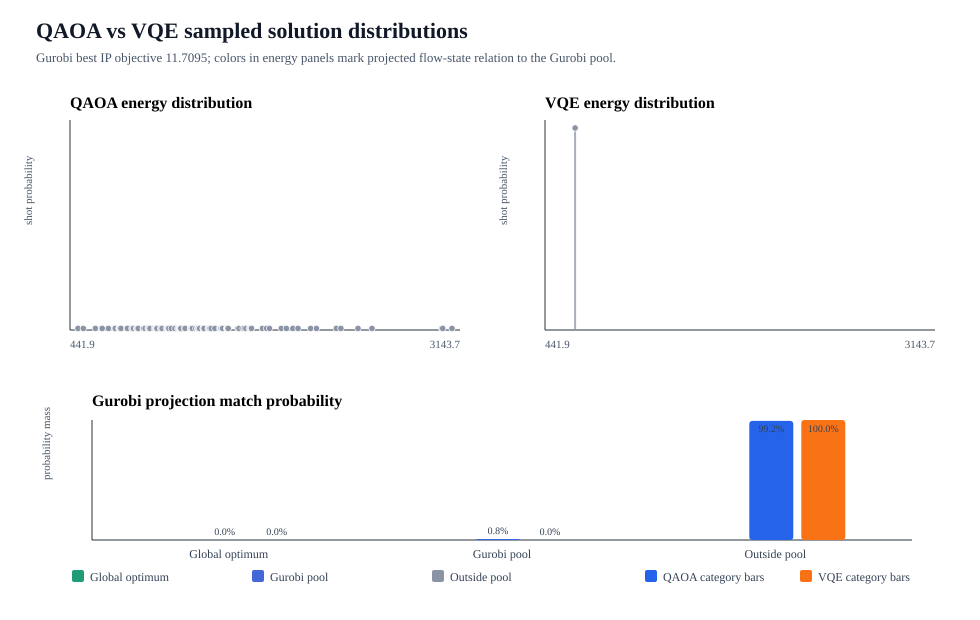

Saved-data figure written to: /home/bernalde/repos/QiskitOpt.jl/ds_mfg_student_package_20260605/ds_mfg_qaoa_vqe_distribution_from_saved.svg


In [9]:
saved_distributions = load_saved_distributions()
saved_figure_svg = distribution_comparison_svg(saved_distributions, gurobi)
saved_figure_path = joinpath(REPO_ROOT, "ds_mfg_qaoa_vqe_distribution_from_saved.svg")
write(saved_figure_path, saved_figure_svg)
try
    display("image/svg+xml", saved_figure_svg)
catch err
    println("Inline SVG display is available in Jupyter/IJulia; plain Julia wrote the file but cannot render it inline: ", typeof(err))
end
println("Saved-data figure written to: ", saved_figure_path)


## Generated Comparison Figure

The final code cell writes and displays the same figure. The static preview below points at the figure generated by the latest local run.

![QAOA and VQE sampled distribution comparison](ds_mfg_qaoa_vqe_distribution.svg)


## QAOA Results: Repair, Final Sampling, And Better Angles

The Qiskit samples are full 36-bit QUBO strings: 19 flow bits followed by 17 auxiliary/slack bits. The Gurobi pool is indexed by the 19 flow bits, so a projected pool hit can still have the wrong auxiliary encoding and therefore a much larger raw QUBO energy.

This section reports both views. `projection` asks whether the sampled flow bits appear in the Gurobi pool. `encoded` asks whether the sampled auxiliary bits already match the minimum-energy QUBO extension for that flow. `repaired` replaces the auxiliary bits by that exact minimum-energy completion and then scores the resulting full QUBO string.

Cached QAOA progression:

- Fixed-angle QAOA p=2 found 1 projected Gurobi-pool read out of 128. The sampled auxiliary bits were not encoded correctly, but exact auxiliary repair scores that flow at 18.0745.
- Small p=2 angle perturbations with sigma 0.05, 0.10, and 0.20 did not produce a Gurobi-pool projection hit in the bounded cached runs; sigma 0.10 had the best repaired objective among those perturbation runs, 86.8695.
- Separating optimizer reads from final sampling helped the full 36-variable p=2 run: 128 optimizer reads and 512 final reads found 3 projected pool reads, and the best repaired pool objective improved to 14.5505.
- The largest QAOA improvement came from optimizing angles offline on the 19-variable reduced surrogate with JuliQAOA, then transferring those angles to `QiskitOpt.QAOA` with `MaximumIterations() = 0` for final Aer sampling. The p=5 transferred-angle run sampled the Gurobi global optimum 664 times in 262144 reads. This is the accepted QAOA result for the notebook, and no later run supersedes it.


In [10]:
function csv_column_map(header)
    return Dict(name => i for (i, name) in enumerate(header))
end

function csv_value(row, column, name; default="-")
    haskey(column, name) || return default
    index = column[name]
    index <= length(row) || return default
    value = row[index]
    isempty(strip(value)) ? default : value
end

function print_csv_table(path, columns; limit=20, title=basename(path))
    if !isfile(path)
        println("Missing cached report: ", path)
        return
    end

    header, rows = read_simple_csv(path)
    column = csv_column_map(header)
    selected_rows = rows[1:min(limit, length(rows))]
    table = [[csv_value(row, column, name) for name in columns] for row in selected_rows]
    widths = [length(name) for name in columns]
    for row in table
        for (i, value) in enumerate(row)
            widths[i] = max(widths[i], length(value))
        end
    end

    println(title, " (showing ", length(selected_rows), " of ", length(rows), " rows)")
    println(join([rpad(columns[i], widths[i]) for i in eachindex(columns)], "  "))
    println(join([repeat("-", widths[i]) for i in eachindex(columns)], "  "))
    for row in table
        println(join([rpad(row[i], widths[i]) for i in eachindex(columns)], "  "))
    end
end

repair_summary_path = joinpath(REPO_ROOT, "ds_mfg_aux_repair_analysis", "repair_summary.csv")
final_sampling_summary_path = joinpath(REPO_ROOT, "ds_mfg_final_sampling_sweep_v2", "final_sampling_summary.csv")
perturbation_summary_path = joinpath(REPO_ROOT, "ds_mfg_p2_perturbation_sweep_v3", "p2_perturbation_summary.csv")
fixed_angle_summary_path = joinpath(REPO_ROOT, "ds_mfg_fixed_angle_sweep", "fixed_angle_qaoa_summary.csv")
qaoa_juliqaoa_angle_summary_path = joinpath(REPO_ROOT, "ds_mfg_qaoa_juliqaoa_angle_search", "juliqaoa_angle_summary.csv")
qaoa_juliqaoa_transfer_summary_path = joinpath(REPO_ROOT, "ds_mfg_qaoa_juliqaoa_transfer", "qaoa_juliqaoa_transfer_summary.csv")
qaoa_juliqaoa_transfer_highread_summary_path = joinpath(REPO_ROOT, "ds_mfg_qaoa_juliqaoa_transfer_highread", "qaoa_juliqaoa_transfer_summary.csv")
qaoa_juliqaoa_angle_final_summary_path = joinpath(REPO_ROOT, "ds_mfg_qaoa_juliqaoa_angle_search_final", "juliqaoa_angle_summary.csv")
qaoa_juliqaoa_transfer_final_summary_path = joinpath(REPO_ROOT, "ds_mfg_qaoa_juliqaoa_transfer_final", "qaoa_juliqaoa_transfer_summary.csv")

print_csv_table(
    fixed_angle_summary_path,
    ["p", "total_reads", "pool_reads", "encoded_pool_reads", "best_qubo_energy", "best_match", "best_encoded_match", "best_flow_bits"],
    limit = 10,
    title = "Fixed-angle QAOA p sweep",
)
println()
print_csv_table(
    repair_summary_path,
    ["source_csv", "total_reads", "projected_pool_reads", "repaired_pool_reads", "best_raw_qubo_energy", "best_repaired_qubo_energy", "best_repaired_match", "best_repaired_flow_bits"],
    limit = 20,
    title = "Exact auxiliary repair over saved distributions",
)
println()
print_csv_table(
    perturbation_summary_path,
    ["sigma", "total_reads", "projected_pool_reads", "encoded_pool_reads", "best_repaired_qubo_energy", "best_repaired_match", "best_repaired_flow_bits"],
    limit = 10,
    title = "p=2 fixed-angle perturbation sweep",
)
println()
print_csv_table(
    final_sampling_summary_path,
    ["p", "optimizer_reads", "final_reads", "total_reads", "projected_pool_reads", "encoded_pool_reads", "best_repaired_qubo_energy", "best_repaired_match", "best_repaired_flow_bits"],
    limit = 10,
    title = "p=2 final sampling with separate optimizer/final reads",
)
println()
print_csv_table(
    qaoa_juliqaoa_angle_summary_path,
    ["target", "p", "juliqaoa_expected_surrogate_energy", "top50_probability", "top10_probability", "global_probability", "best_top50_rank_by_probability", "best_top50_flow_bits"],
    limit = 10,
    title = "JuliQAOA reduced-surrogate angle search",
)
println()
print_csv_table(
    qaoa_juliqaoa_transfer_summary_path,
    ["angle_target", "p", "final_reads", "top50_hits", "top10_hits", "global_hits", "best_top50_rank", "best_top50_exact_repaired_qubo_energy", "juliqaoa_global_probability"],
    limit = 10,
    title = "QiskitOpt QAOA with transferred JuliQAOA angles",
)
println()
print_csv_table(
    qaoa_juliqaoa_transfer_highread_summary_path,
    ["angle_target", "p", "final_reads", "top50_hits", "top10_hits", "global_hits", "best_top50_rank", "best_top50_exact_repaired_qubo_energy", "juliqaoa_global_probability"],
    limit = 10,
    title = "QiskitOpt QAOA transferred-angle high-read follow-up",
)
if isfile(qaoa_juliqaoa_angle_final_summary_path)
    println()
    print_csv_table(
        qaoa_juliqaoa_angle_final_summary_path,
        ["target", "p", "juliqaoa_expected_surrogate_energy", "top50_probability", "top10_probability", "global_probability", "best_top50_rank_by_probability", "best_top50_flow_bits"],
        limit = 10,
        title = "Final deeper JuliQAOA angle-search pass",
    )
end
if isfile(qaoa_juliqaoa_transfer_final_summary_path)
    println()
    print_csv_table(
        qaoa_juliqaoa_transfer_final_summary_path,
        ["angle_target", "p", "final_reads", "top50_hits", "top10_hits", "global_hits", "best_top50_rank", "best_top50_exact_repaired_qubo_energy", "juliqaoa_global_probability"],
        limit = 10,
        title = "Final QiskitOpt QAOA transferred-angle follow-up",
    )
end


Fixed-angle QAOA p sweep (showing 5 of 5 rows)
p  total_reads  pool_reads  encoded_pool_reads  best_qubo_energy    best_match          best_encoded_match           best_flow_bits     
-  -----------  ----------  ------------------  ------------------  ------------------  ---------------------------  -------------------
1  128          0           0                   310.9549999999998   not_in_gurobi_pool  not_in_gurobi_pool           1100000000111010011
2  128          1           0                   189.06769999999995  gurobi_pool         projection_only_gurobi_pool  1001110101011100011
3  128          0           0                   350.32629999999983  not_in_gurobi_pool  not_in_gurobi_pool           1100101100100000001
4  128          0           0                   367.68439999999975  not_in_gurobi_pool  not_in_gurobi_pool           0000110110110000101
5  128          0           0                   307.5889999999998   not_in_gurobi_pool  not_in_gurobi_pool           10100011001000

## QAOA Reduced Flow-Only Objective

The auxiliary variables split into 13 independent components after the 19 flow variables are fixed. That lets us eliminate the 17 auxiliary bits exactly by minimizing each small component independently. The resulting exact flow-only objective is not generally quadratic, so it cannot be passed directly through the current QUBO-only QAOA interface.

The reduction tested here is:

1. Build the exact 19-variable repaired objective by auxiliary elimination.
2. Enumerate all `2^19` flow strings to verify the exact reduced optimum.
3. Fit the best least-squares quadratic surrogate over all `2^19` exact repaired energies.
4. Run QAOA on that 19-variable surrogate and score the returned samples with the exact reduced objective.

Current cached result: exact elimination recovers the Gurobi optimum 11.7095 at flow `1001110100111100011`. The quadratic surrogate has high global fit quality (`R^2 = 0.9990818775`, RMSE 14.3879), but its deterministic minimum is the Gurobi-pool flow `1001110110011100011` with exact repaired objective 14.5505 rather than the global optimum. The QAOA run on the surrogate with p=2, 128 optimizer reads, 512 final reads, and 25 COBYLA iterations did not sample a Gurobi-pool flow; its best exact repaired sampled objective was 102.7385.


In [11]:
reduced_summary_path = joinpath(REPO_ROOT, "ds_mfg_reduced_flow_objective", "reduced_flow_summary.csv")
reduced_top_path = joinpath(REPO_ROOT, "ds_mfg_reduced_flow_objective", "reduced_exact_top_flows.csv")
reduced_components_path = joinpath(REPO_ROOT, "ds_mfg_reduced_flow_objective", "auxiliary_components.csv")
reduced_distribution_path = joinpath(REPO_ROOT, "ds_mfg_reduced_flow_objective", "qaoa_reduced_surrogate_p2_optimizer_reads128_final_reads512_iter25_distribution.csv")

print_csv_table(
    reduced_summary_path,
    ["exact_global_reduced_energy", "exact_global_flow_bits", "gurobi_best_objective", "quadratic_fit_rmse", "quadratic_fit_r2", "surrogate_global_flow_bits", "surrogate_global_exact_repaired_energy", "total_reads", "global_reads", "pool_reads", "best_sample_exact_repaired_qubo_energy", "best_sample_match", "best_sample_flow_bits"],
    limit = 5,
    title = "Reduced flow-only objective and QAOA surrogate summary",
)
println()
print_csv_table(
    reduced_components_path,
    ["component_id", "aux_indices", "flow_neighbors", "n_aux", "n_flow_neighbors"],
    limit = 20,
    title = "Auxiliary components eliminated exactly",
)
println()
print_csv_table(
    reduced_top_path,
    ["rank", "exact_repaired_qubo_energy", "flow_bits", "repaired_aux_bits", "match", "matched_ip_obj"],
    limit = 15,
    title = "Top exact reduced-flow assignments",
)
println()
print_csv_table(
    reduced_distribution_path,
    ["result", "reads", "probability", "surrogate_qubo_energy", "exact_repaired_qubo_energy", "match", "flow_bits", "repaired_aux_bits"],
    limit = 15,
    title = "Reduced-surrogate QAOA sampled distribution scored by exact repair",
)


Reduced flow-only objective and QAOA surrogate summary (showing 1 of 1 rows)
exact_global_reduced_energy  exact_global_flow_bits  gurobi_best_objective  quadratic_fit_rmse  quadratic_fit_r2    surrogate_global_flow_bits  surrogate_global_exact_repaired_energy  total_reads  global_reads  pool_reads  best_sample_exact_repaired_qubo_energy  best_sample_match   best_sample_flow_bits
---------------------------  ----------------------  ---------------------  ------------------  ------------------  --------------------------  --------------------------------------  -----------  ------------  ----------  --------------------------------------  ------------------  ---------------------
11.70949999999975            1001110100111100011     11.7095                14.387915045252994  0.9990818774614971  1001110110011100011         14.550499999999772                      512          0             0           102.73849999999999                      not_in_gurobi_pool  1100110101011000011  

Auxilia

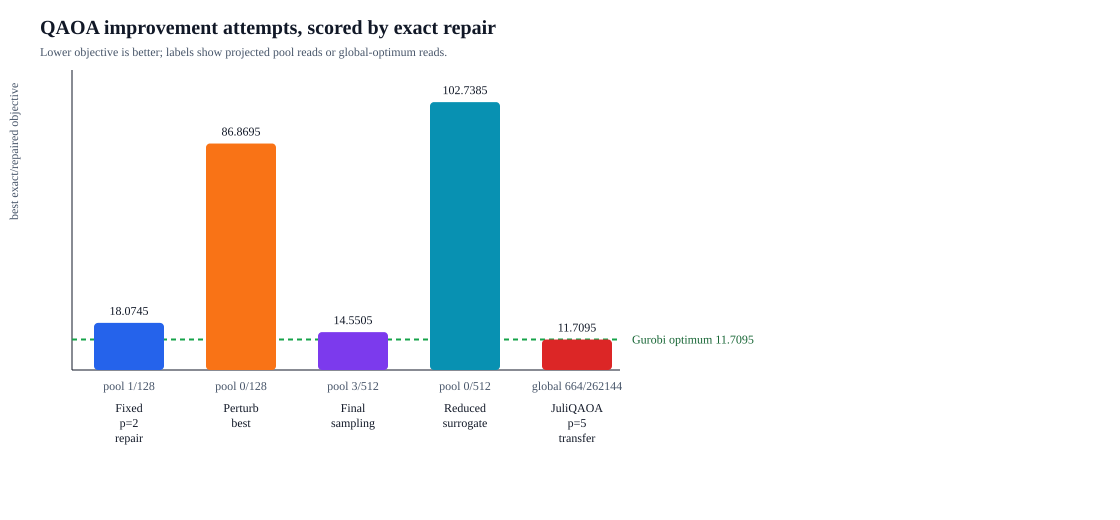

QAOA improvement comparison figure written to: /home/bernalde/repos/QiskitOpt.jl/ds_mfg_student_package_20260605/ds_mfg_qaoa_improvement_comparison.svg


In [12]:
function csv_dict_rows(path)
    header, rows = read_simple_csv(path)
    column = csv_column_map(header)
    return [Dict(name => csv_value(row, column, name; default="") for name in header) for row in rows]
end

function csv_float(row, name; default=NaN)
    value = strip(get(row, name, ""))
    isempty(value) && return default
    return parse(Float64, value)
end

function csv_int(row, name; default=0)
    value = strip(get(row, name, ""))
    isempty(value) && return default
    return parse(Int, value)
end

function optional_first_row(path)
    isfile(path) || return nothing
    rows = csv_dict_rows(path)
    isempty(rows) && return nothing
    return first(rows)
end

function qaoa_improvement_rows()
    repair_rows = csv_dict_rows(repair_summary_path)
    p2_repair = only(filter(row -> occursin("qaoa_fac_p2", row["source_csv"]), repair_rows))
    perturb_rows = csv_dict_rows(perturbation_summary_path)
    best_perturb = perturb_rows[argmin([csv_float(row, "best_repaired_qubo_energy") for row in perturb_rows])]
    final_sampling = first(csv_dict_rows(final_sampling_summary_path))
    reduced_summary = first(csv_dict_rows(joinpath(REPO_ROOT, "ds_mfg_reduced_flow_objective", "reduced_flow_summary.csv")))
    qaoa_transfer = first(csv_dict_rows(qaoa_juliqaoa_transfer_highread_summary_path))
    final_transfer = optional_first_row(qaoa_juliqaoa_transfer_final_summary_path)

    rows = [
        (label="Fixed p=2 repair", best=csv_float(p2_repair, "best_repaired_qubo_energy"), hit_label=@sprintf("pool %d/%d", csv_int(p2_repair, "repaired_pool_reads"), csv_int(p2_repair, "total_reads"))),
        (label="Perturb best", best=csv_float(best_perturb, "best_repaired_qubo_energy"), hit_label=@sprintf("pool %d/%d", csv_int(best_perturb, "projected_pool_reads"), csv_int(best_perturb, "total_reads"))),
        (label="Final sampling", best=csv_float(final_sampling, "best_repaired_qubo_energy"), hit_label=@sprintf("pool %d/%d", csv_int(final_sampling, "projected_pool_reads"), csv_int(final_sampling, "total_reads"))),
        (label="Reduced surrogate", best=csv_float(reduced_summary, "best_sample_exact_repaired_qubo_energy"), hit_label=@sprintf("pool %d/%d", csv_int(reduced_summary, "pool_reads"), csv_int(reduced_summary, "total_reads"))),
        (label="JuliQAOA p=5 transfer", best=csv_float(qaoa_transfer, "best_top50_exact_repaired_qubo_energy"), hit_label=@sprintf("global %d/%d", csv_int(qaoa_transfer, "global_hits"), csv_int(qaoa_transfer, "total_reads"))),
    ]
    if !isnothing(final_transfer)
        push!(rows, (label="Final JuliQAOA transfer", best=csv_float(final_transfer, "best_top50_exact_repaired_qubo_energy"), hit_label=@sprintf("global %d/%d", csv_int(final_transfer, "global_hits"), csv_int(final_transfer, "total_reads"))))
    end
    return rows
end

function qaoa_improvement_svg(rows, gurobi_best)
    width = 1120
    height = 520
    margin_left = 72
    bar_w = 70
    gap = 42
    chart_x = margin_left
    chart_y = 70
    chart_h = 300
    chart_w = length(rows) * bar_w + (length(rows) - 1) * gap
    max_best = maximum(row.best for row in rows)
    ymax = max_best * 1.12
    parts = String[]
    push!(parts, "<svg xmlns='http://www.w3.org/2000/svg' width='$(width)' height='$(height)' viewBox='0 0 $(width) $(height)'>")
    push!(parts, "<rect width='100%' height='100%' fill='white'/>")
    push!(parts, "<text x='40' y='34' font-size='20' font-weight='700' fill='#111827'>QAOA improvement attempts, scored by exact repair</text>")
    push!(parts, "<text x='40' y='56' font-size='12' fill='#475569'>Lower objective is better; labels show projected pool reads or global-optimum reads.</text>")
    push!(parts, @sprintf("<line x1='%d' y1='%d' x2='%d' y2='%d' stroke='#111827'/>", chart_x, chart_y + chart_h, chart_x + chart_w + 30, chart_y + chart_h))
    push!(parts, @sprintf("<line x1='%d' y1='%d' x2='%d' y2='%d' stroke='#111827'/>", chart_x, chart_y, chart_x, chart_y + chart_h))
    gy = chart_y + chart_h - gurobi_best / ymax * chart_h
    push!(parts, @sprintf("<line x1='%d' y1='%.1f' x2='%d' y2='%.1f' stroke='#16a34a' stroke-width='2' stroke-dasharray='5 4'/>", chart_x, gy, chart_x + chart_w + 30, gy))
    push!(parts, @sprintf("<text x='%d' y='%.1f' font-size='12' fill='#166534'>Gurobi optimum %.4f</text>", chart_x + chart_w + 42, gy + 4, gurobi_best))
    colors = ["#2563eb", "#f97316", "#7c3aed", "#0891b2", "#dc2626", "#1f9d78"]
    for (i, row) in enumerate(rows)
        x = chart_x + 22 + (i - 1) * (bar_w + gap)
        h = row.best / ymax * chart_h
        y = chart_y + chart_h - h
        push!(parts, @sprintf("<rect x='%.1f' y='%.1f' width='%d' height='%.1f' rx='4' fill='%s'/>", x, y, bar_w, h, colors[mod1(i, length(colors))]))
        push!(parts, @sprintf("<text x='%.1f' y='%.1f' font-size='12' text-anchor='middle' fill='#111827'>%.4f</text>", x + bar_w / 2, y - 8, row.best))
        push!(parts, @sprintf("<text x='%.1f' y='%.1f' font-size='12' text-anchor='middle' fill='#475569'>%s</text>", x + bar_w / 2, chart_y + chart_h + 20, svg_escape(row.hit_label)))
        for (j, word) in enumerate(split(row.label))
            push!(parts, @sprintf("<text x='%.1f' y='%.1f' font-size='12' text-anchor='middle' fill='#111827'>%s</text>", x + bar_w / 2, chart_y + chart_h + 42 + 15 * (j - 1), svg_escape(word)))
        end
    end
    push!(parts, @sprintf("<text x='18' y='220' font-size='12' fill='#475569' transform='rotate(-90 18 220)'>best exact/repaired objective</text>"))
    push!(parts, "</svg>")
    return join(parts, "
")
end

improvement_rows = qaoa_improvement_rows()
improvement_svg = qaoa_improvement_svg(improvement_rows, gurobi.best_objective)
improvement_figure_path = joinpath(REPO_ROOT, "ds_mfg_qaoa_improvement_comparison.svg")
write(improvement_figure_path, improvement_svg)
try
    display("image/svg+xml", improvement_svg)
catch err
    println("Inline SVG display is available in Jupyter/IJulia; plain Julia wrote the file but cannot render it inline: ", typeof(err))
end
println("QAOA improvement comparison figure written to: ", improvement_figure_path)


## VQE Results: Final Sampling And Reduced Surrogate

VQE was tested with the same two ideas used for QAOA: separate optimizer shots from final sampling shots, and score samples after exact auxiliary repair. The package exposes `QUBODrivers.FinalNumberOfReads()` so the final sampler can use more reads without increasing the estimator cost at every COBYLA step.

The first VQE run used one random EfficientSU2 initialization with 128 optimizer reads, 512 final reads, and 25 iterations. Then a 5-seed sweep used the same optimizer settings but increased final sampling to 8192 reads per seed for both the full 36-variable QUBO and the 19-variable reduced quadratic surrogate.

After updating to `QiskitOpt v0.4.1`, the reduced-surrogate VQE experiment was repeated with the package-level Aer MPS attributes enabled. A 20-seed sweep with 32768 final reads per seed sampled the Gurobi global optimum 3 times, and a high-read follow-up on the best seeds with 262144 final reads per seed sampled it 19 times. The final follow-up doubled final sampling to 524288 reads on seeds 74018, 74007, and 74001; it sampled the global optimum 28 times total, with seed 74018 contributing 20 reads. These hits are rare, but they are present in the cached distribution.


### Why VQE Was Revisited

The small full-QUBO VQE baselines did not produce a useful pool hit. The later VQE experiments change two things: they separate optimizer shots from final sampling shots, and they run several random EfficientSU2 initializations. This makes VQE a stronger sampling baseline without making every optimizer step expensive. The final 524288-read runs confirm that VQE can repeatedly sample the global optimum on the reduced surrogate, but its hit rate remains much lower than the transferred-angle QAOA run.


In [13]:
vqe_single_summary_path = joinpath(REPO_ROOT, "ds_mfg_vqe_final_sampling_sweep", "vqe_final_sampling_summary.csv")
vqe_single_reduced_summary_path = joinpath(REPO_ROOT, "ds_mfg_vqe_reduced_flow_objective", "vqe_reduced_flow_summary.csv")
vqe_full_sweep_summary_path = joinpath(REPO_ROOT, "ds_mfg_vqe_final_sampling_sweep_v2", "vqe_final_sampling_summary.csv")
vqe_reduced_sweep_summary_path = joinpath(REPO_ROOT, "ds_mfg_vqe_reduced_flow_objective_v2", "vqe_reduced_flow_summary.csv")
vqe_reduced_top50_summary_path = joinpath(REPO_ROOT, "ds_mfg_vqe_reduced_flow_objective_v3", "vqe_reduced_top50_sampling_summary.csv")
vqe_reduced_top50_highread_summary_path = joinpath(REPO_ROOT, "ds_mfg_vqe_reduced_flow_objective_v4", "vqe_reduced_top50_sampling_summary.csv")
vqe_reduced_top50_final_summary_path = joinpath(REPO_ROOT, "ds_mfg_vqe_reduced_flow_objective_final", "vqe_reduced_top50_sampling_summary.csv")

print_csv_table(
    vqe_single_summary_path,
    ["algorithm", "seed", "optimizer_reads", "final_reads", "total_reads", "pool_reads", "encoded_pool_reads", "best_repaired_qubo_energy", "best_repaired_match", "best_repaired_flow_bits"],
    limit = 10,
    title = "Full VQE, random initialization, 512 final reads",
)
println()
print_csv_table(
    vqe_single_reduced_summary_path,
    ["algorithm", "seed", "optimizer_reads", "final_reads", "total_reads", "pool_reads", "best_sample_exact_repaired_qubo_energy", "best_sample_match", "best_sample_flow_bits"],
    limit = 10,
    title = "Reduced-surrogate VQE, random initialization, 512 final reads",
)
println()
print_csv_table(
    vqe_full_sweep_summary_path,
    ["seed", "final_reads", "total_reads", "pool_reads", "encoded_pool_reads", "best_repaired_qubo_energy", "best_repaired_match", "best_repaired_flow_bits"],
    limit = 10,
    title = "Full VQE, 5 random seeds, 8192 final reads each",
)
println()
print_csv_table(
    vqe_reduced_sweep_summary_path,
    ["seed", "final_reads", "total_reads", "pool_reads", "best_sample_exact_repaired_qubo_energy", "best_sample_match", "best_sample_flow_bits"],
    limit = 10,
    title = "Reduced-surrogate VQE, 5 random seeds, 8192 final reads each",
)
println()
print_csv_table(
    vqe_reduced_top50_summary_path,
    ["seed", "final_reads", "total_reads", "top50_hits", "top10_hits", "global_hits", "best_top50_rank", "best_top50_exact_repaired_qubo_energy", "best_top50_match", "best_top50_flow_bits"],
    limit = 25,
    title = "Reduced-surrogate VQE, 20 seeds, 32768 final reads each",
)
println()
print_csv_table(
    vqe_reduced_top50_highread_summary_path,
    ["seed", "final_reads", "total_reads", "top50_hits", "top10_hits", "global_hits", "best_top50_rank", "best_top50_exact_repaired_qubo_energy", "best_top50_match", "best_top50_flow_bits"],
    limit = 10,
    title = "Reduced-surrogate VQE, high-read follow-up on selected seeds",
)
println()
print_csv_table(
    vqe_reduced_top50_final_summary_path,
    ["seed", "final_reads", "total_reads", "top50_hits", "top10_hits", "global_hits", "best_top50_rank", "best_top50_exact_repaired_qubo_energy", "best_top50_match", "best_top50_flow_bits"],
    limit = 10,
    title = "Final reduced-surrogate VQE follow-up",
)


Full VQE, random initialization, 512 final reads (showing 1 of 1 rows)
algorithm  seed   optimizer_reads  final_reads  total_reads  pool_reads  encoded_pool_reads  best_repaired_qubo_energy  best_repaired_match  best_repaired_flow_bits
---------  -----  ---------------  -----------  -----------  ----------  ------------------  -------------------------  -------------------  -----------------------
VQE        73001  128              512          512          0           0                   106.98949999999991         not_in_gurobi_pool   1100101100111000101    

Reduced-surrogate VQE, random initialization, 512 final reads (showing 1 of 1 rows)
algorithm              seed   optimizer_reads  final_reads  total_reads  pool_reads  best_sample_exact_repaired_qubo_energy  best_sample_match   best_sample_flow_bits
---------------------  -----  ---------------  -----------  -----------  ----------  --------------------------------------  ------------------  ---------------------
VQE_reduced_sur

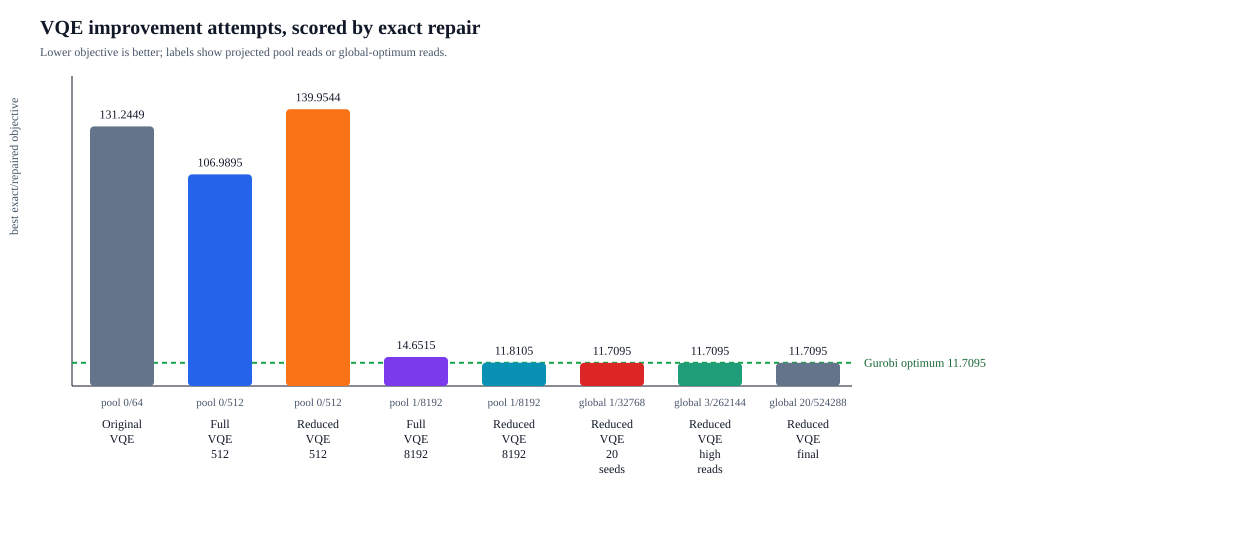

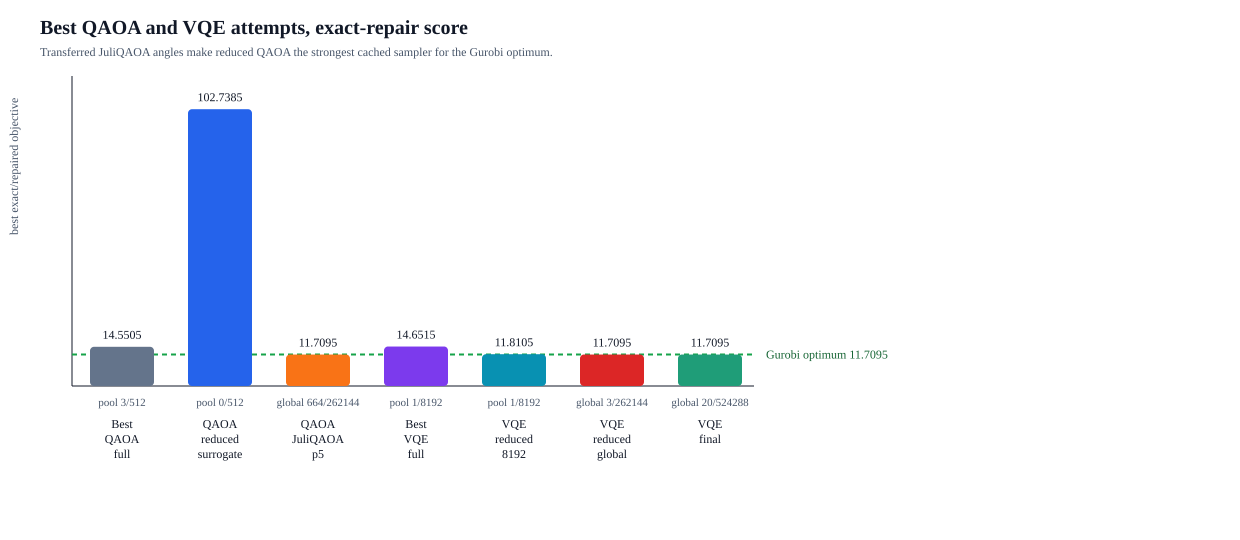

VQE improvement figure written to: /home/bernalde/repos/QiskitOpt.jl/ds_mfg_student_package_20260605/ds_mfg_vqe_improvement_comparison.svg
Best QAOA/VQE repaired comparison figure written to: /home/bernalde/repos/QiskitOpt.jl/ds_mfg_student_package_20260605/ds_mfg_qaoa_vqe_best_repaired_comparison.svg


In [14]:
function row_with_min(rows, column)
    return rows[argmin([csv_float(row, column) for row in rows])]
end

function row_with_min_nonempty(rows, column)
    filtered = filter(row -> !isempty(strip(get(row, column, ""))), rows)
    isempty(filtered) && error("No rows with nonempty column $(column)")
    return row_with_min(filtered, column)
end

function pool_label(row; total_name="total_reads")
    for name in ("projected_pool_reads", "pool_reads", "repaired_pool_reads")
        if haskey(row, name)
            return "pool $(row[name])/$(row[total_name])"
        end
    end
    return "pool -/$(get(row, total_name, "-"))"
end

function top50_global_label(row)
    return "global $(csv_int(row, "global_hits"))/$(csv_int(row, "total_reads"))"
end

function write_repaired_bar_svg(path, title, subtitle, rows; gurobi_best=gurobi.best_objective)
    width = 1240
    height = 540
    chart_x = 72
    chart_y = 76
    chart_h = 310
    bar_w = 64
    gap = 34
    chart_w = length(rows) * bar_w + (length(rows) - 1) * gap
    ymax = max(maximum(row.value for row in rows), gurobi_best) * 1.12
    colors = ["#64748b", "#2563eb", "#f97316", "#7c3aed", "#0891b2", "#dc2626", "#1f9d78"]
    parts = String[]
    push!(parts, "<svg xmlns='http://www.w3.org/2000/svg' width='$(width)' height='$(height)' viewBox='0 0 $(width) $(height)'>")
    push!(parts, "<rect width='100%' height='100%' fill='white'/>")
    push!(parts, "<text x='40' y='34' font-size='20' font-weight='700' fill='#111827'>$(svg_escape(title))</text>")
    push!(parts, "<text x='40' y='56' font-size='12' fill='#475569'>$(svg_escape(subtitle))</text>")
    push!(parts, @sprintf("<line x1='%d' y1='%d' x2='%d' y2='%d' stroke='#111827'/>", chart_x, chart_y + chart_h, chart_x + chart_w + 30, chart_y + chart_h))
    push!(parts, @sprintf("<line x1='%d' y1='%d' x2='%d' y2='%d' stroke='#111827'/>", chart_x, chart_y, chart_x, chart_y + chart_h))
    gy = chart_y + chart_h - gurobi_best / ymax * chart_h
    push!(parts, @sprintf("<line x1='%d' y1='%.1f' x2='%d' y2='%.1f' stroke='#16a34a' stroke-width='2' stroke-dasharray='5 4'/>", chart_x, gy, chart_x + chart_w + 30, gy))
    push!(parts, @sprintf("<text x='%d' y='%.1f' font-size='12' fill='#166534'>Gurobi optimum %.4f</text>", chart_x + chart_w + 42, gy + 4, gurobi_best))

    for (index, row) in enumerate(rows)
        x = chart_x + 18 + (index - 1) * (bar_w + gap)
        h = row.value / ymax * chart_h
        y = chart_y + chart_h - h
        color = colors[mod1(index, length(colors))]
        push!(parts, @sprintf("<rect x='%.1f' y='%.1f' width='%d' height='%.1f' rx='4' fill='%s'/>", x, y, bar_w, h, color))
        push!(parts, @sprintf("<text x='%.1f' y='%.1f' font-size='12' text-anchor='middle' fill='#111827'>%.4f</text>", x + bar_w / 2, y - 8, row.value))
        push!(parts, @sprintf("<text x='%.1f' y='%.1f' font-size='11' text-anchor='middle' fill='#475569'>%s</text>", x + bar_w / 2, chart_y + chart_h + 20, svg_escape(row.pool)))
        for (line_index, word) in enumerate(split(row.label))
            push!(parts, @sprintf("<text x='%.1f' y='%.1f' font-size='12' text-anchor='middle' fill='#111827'>%s</text>", x + bar_w / 2, chart_y + chart_h + 42 + 15 * (line_index - 1), svg_escape(word)))
        end
    end
    push!(parts, "<text x='18' y='235' font-size='12' fill='#475569' transform='rotate(-90 18 235)'>best exact/repaired objective</text>")
    push!(parts, "</svg>")
    write(path, join(parts, "
"))
    return path
end

original_vqe = only(filter(row -> row["source_csv"] == "ds_mfg_saved_distributions/vqe_distribution.csv", csv_dict_rows(repair_summary_path)))
vqe_single = first(csv_dict_rows(vqe_single_summary_path))
vqe_single_reduced = first(csv_dict_rows(vqe_single_reduced_summary_path))
vqe_full_sweep = csv_dict_rows(vqe_full_sweep_summary_path)
vqe_reduced_sweep = csv_dict_rows(vqe_reduced_sweep_summary_path)
vqe_reduced_top50_sweep = csv_dict_rows(vqe_reduced_top50_summary_path)
vqe_reduced_top50_highread = csv_dict_rows(vqe_reduced_top50_highread_summary_path)
vqe_reduced_top50_final = isfile(vqe_reduced_top50_final_summary_path) ? csv_dict_rows(vqe_reduced_top50_final_summary_path) : Dict{String,String}[]
qaoa_transfer_highread = first(csv_dict_rows(qaoa_juliqaoa_transfer_highread_summary_path))
qaoa_transfer_final = optional_first_row(qaoa_juliqaoa_transfer_final_summary_path)
best_vqe_full = row_with_min(vqe_full_sweep, "best_repaired_qubo_energy")
best_vqe_reduced = row_with_min(vqe_reduced_sweep, "best_sample_exact_repaired_qubo_energy")
best_vqe_reduced_top50 = row_with_min_nonempty(vqe_reduced_top50_sweep, "best_top50_exact_repaired_qubo_energy")
best_vqe_reduced_highread = row_with_min_nonempty(vqe_reduced_top50_highread, "best_top50_exact_repaired_qubo_energy")
best_vqe_reduced_final = isempty(vqe_reduced_top50_final) ? nothing : row_with_min_nonempty(vqe_reduced_top50_final, "best_top50_exact_repaired_qubo_energy")
qaoa_final = first(csv_dict_rows(final_sampling_summary_path))
qaoa_reduced = first(csv_dict_rows(reduced_summary_path))

vqe_figure_rows = [
    (label="Original VQE", value=csv_float(original_vqe, "best_repaired_qubo_energy"), pool=pool_label(original_vqe)),
    (label="Full VQE 512", value=csv_float(vqe_single, "best_repaired_qubo_energy"), pool=pool_label(vqe_single)),
    (label="Reduced VQE 512", value=csv_float(vqe_single_reduced, "best_sample_exact_repaired_qubo_energy"), pool=pool_label(vqe_single_reduced)),
    (label="Full VQE 8192", value=csv_float(best_vqe_full, "best_repaired_qubo_energy"), pool=pool_label(best_vqe_full)),
    (label="Reduced VQE 8192", value=csv_float(best_vqe_reduced, "best_sample_exact_repaired_qubo_energy"), pool=pool_label(best_vqe_reduced)),
    (label="Reduced VQE 20 seeds", value=csv_float(best_vqe_reduced_top50, "best_top50_exact_repaired_qubo_energy"), pool=top50_global_label(best_vqe_reduced_top50)),
    (label="Reduced VQE high reads", value=csv_float(best_vqe_reduced_highread, "best_top50_exact_repaired_qubo_energy"), pool=top50_global_label(best_vqe_reduced_highread)),
]
if !isnothing(best_vqe_reduced_final)
    push!(vqe_figure_rows, (label="Reduced VQE final", value=csv_float(best_vqe_reduced_final, "best_top50_exact_repaired_qubo_energy"), pool=top50_global_label(best_vqe_reduced_final)))
end
vqe_figure_path = joinpath(REPO_ROOT, "ds_mfg_vqe_improvement_comparison.svg")
write_repaired_bar_svg(vqe_figure_path, "VQE improvement attempts, scored by exact repair", "Lower objective is better; labels show projected pool reads or global-optimum reads.", vqe_figure_rows)

combined_figure_rows = [
    (label="Best QAOA full", value=csv_float(qaoa_final, "best_repaired_qubo_energy"), pool=pool_label(qaoa_final)),
    (label="QAOA reduced surrogate", value=csv_float(qaoa_reduced, "best_sample_exact_repaired_qubo_energy"), pool=pool_label(qaoa_reduced)),
    (label="QAOA JuliQAOA p5", value=csv_float(qaoa_transfer_highread, "best_top50_exact_repaired_qubo_energy"), pool=top50_global_label(qaoa_transfer_highread)),
]
if !isnothing(qaoa_transfer_final)
    push!(combined_figure_rows, (label="QAOA final transfer", value=csv_float(qaoa_transfer_final, "best_top50_exact_repaired_qubo_energy"), pool=top50_global_label(qaoa_transfer_final)))
end
append!(combined_figure_rows, [
    (label="Best VQE full", value=csv_float(best_vqe_full, "best_repaired_qubo_energy"), pool=pool_label(best_vqe_full)),
    (label="VQE reduced 8192", value=csv_float(best_vqe_reduced, "best_sample_exact_repaired_qubo_energy"), pool=pool_label(best_vqe_reduced)),
    (label="VQE reduced global", value=csv_float(best_vqe_reduced_highread, "best_top50_exact_repaired_qubo_energy"), pool=top50_global_label(best_vqe_reduced_highread)),
])
if !isnothing(best_vqe_reduced_final)
    push!(combined_figure_rows, (label="VQE final", value=csv_float(best_vqe_reduced_final, "best_top50_exact_repaired_qubo_energy"), pool=top50_global_label(best_vqe_reduced_final)))
end
combined_figure_path = joinpath(REPO_ROOT, "ds_mfg_qaoa_vqe_best_repaired_comparison.svg")
write_repaired_bar_svg(combined_figure_path, "Best QAOA and VQE attempts, exact-repair score", "Transferred JuliQAOA angles make reduced QAOA the strongest cached sampler for the Gurobi optimum.", combined_figure_rows)

try
    display("image/svg+xml", read(vqe_figure_path, String))
    display("image/svg+xml", read(combined_figure_path, String))
catch err
    println("Inline SVG display is available in Jupyter/IJulia; plain Julia wrote the files but cannot render them inline: ", typeof(err))
end
println("VQE improvement figure written to: ", vqe_figure_path)
println("Best QAOA/VQE repaired comparison figure written to: ", combined_figure_path)


## Hardware Run Placeholders

The notebook results above are local Aer simulations. The following placeholder cell records the hardware run plan using the best cached settings from the local study.

QAOA has a hardware-ready fixed parameter vector: the p=5 beta-then-gamma angles learned by JuliQAOA on the reduced 19-flow quadratic surrogate. The cached Aer follow-up with these angles sampled the Gurobi global optimum 664 times in 262144 final reads, so this is the primary hardware candidate.

VQE should be treated differently. The current cache identifies the best VQE reduced-surrogate configuration as seed 74018 with EfficientSU2, 128 optimizer shots, 25 COBYLA iterations, and 524288 final Aer reads. That cache does not persist the final optimized ansatz vector. The VQE hardware placeholder therefore reruns VQE from the best initial seed unless the package/script is later extended to persist and reload the optimized `result.x` parameter vector.

By default this cell only prints the planned settings. To submit hardware jobs, set `DSMFG_RUN_IBM_HARDWARE=true` and configure IBM Runtime credentials and backend environment variables before executing the notebook.


In [15]:
hardware_reduced_dir = joinpath(REPO_ROOT, "ds_mfg_reduced_flow_objective")

function hardware_read_reduced_scalars(path)
    rows = readlines(path)
    values = split(rows[2], ',')
    return (
        n = round(Int, parse(Float64, values[1])),
        scale = parse(Float64, values[2]),
        offset = parse(Float64, values[3]),
    )
end

function hardware_read_reduced_vector(path)
    values = Float64[]
    for row in readlines(path)[2:end]
        parts = split(row, ',')
        push!(values, parse(Float64, parts[2]))
    end
    return values
end

function hardware_read_reduced_matrix(path)
    rows = readlines(path)[2:end]
    matrix = Matrix{Float64}(undef, length(rows), length(rows))
    for (i, row) in enumerate(rows)
        parts = split(row, ',')
        for j in 1:length(rows)
            matrix[i, j] = parse(Float64, parts[j + 1])
        end
    end
    return matrix
end

function hardware_parse_float_vector(text)
    return [parse(Float64, part) for part in split(text, ';') if !isempty(strip(part))]
end

hardware_scalars = hardware_read_reduced_scalars(joinpath(hardware_reduced_dir, "reduced_scalars.csv"))
hardware_L = hardware_read_reduced_vector(joinpath(hardware_reduced_dir, "reduced_L_vector.csv"))
hardware_Q = hardware_read_reduced_matrix(joinpath(hardware_reduced_dir, "reduced_Q_matrix.csv"))

hardware_qaoa_angle_rows = csv_dict_rows(qaoa_juliqaoa_angle_summary_path)
hardware_best_qaoa_angle_row = only(filter(row -> row["target"] == "energy" && row["p"] == "5", hardware_qaoa_angle_rows))
hardware_qaoa_initial_parameters = hardware_parse_float_vector(hardware_best_qaoa_angle_row["qiskit_angles_beta_then_gamma"])

hardware_best_vqe_seed = 74018
hardware_vqe_initial_parameters = VQE.random_initial_parameters(n_variables = hardware_scalars.n, seed = hardware_best_vqe_seed)

RUN_IBM_HARDWARE = lowercase(get(ENV, "DSMFG_RUN_IBM_HARDWARE", "false")) == "true"
IBM_BACKEND = get(ENV, "QISKIT_IBM_BACKEND", "TODO_BACKEND")
IBM_CHANNEL = get(ENV, "QISKIT_IBM_CHANNEL", "ibm_quantum_platform")
IBM_INSTANCE = get(ENV, "QISKIT_IBM_INSTANCE", "")
IBM_OPTIMIZER_READS = parse(Int, get(ENV, "DSMFG_HARDWARE_OPTIMIZER_READS", "128"))
IBM_FINAL_READS = parse(Int, get(ENV, "DSMFG_HARDWARE_FINAL_READS", "8192"))
IBM_TRANSPILE_SEED = parse(Int, get(ENV, "DSMFG_HARDWARE_TRANSPILE_SEED", "92001"))

function configure_ibm_runtime!(model, algorithm_module; backend, optimizer_reads, final_reads, transpile_seed)
    backend == "TODO_BACKEND" && error("Set QISKIT_IBM_BACKEND before enabling hardware submission")
    MOI.set(model, algorithm_module.IBMBackend(), backend)
    MOI.set(model, algorithm_module.IsLocal(), false)
    MOI.set(model, algorithm_module.Channel(), IBM_CHANNEL)
    isempty(IBM_INSTANCE) || MOI.set(model, algorithm_module.Instance(), IBM_INSTANCE)
    MOI.set(model, algorithm_module.NumberOfReads(), optimizer_reads)
    MOI.set(model, QUBODrivers.FinalNumberOfReads(), final_reads)
    MOI.set(model, algorithm_module.TranspilerSeed(), transpile_seed)
    return model
end

println("Hardware placeholders are disabled by default: DSMFG_RUN_IBM_HARDWARE=", RUN_IBM_HARDWARE)
println("QAOA hardware candidate: reduced 19-flow surrogate, p=5, fixed JuliQAOA angles, MaximumIterations=0")
println("  QAOA parameters beta-then-gamma = ", join((@sprintf("%.12g", value) for value in hardware_qaoa_initial_parameters), ";"))
println("VQE hardware candidate: reduced 19-flow surrogate, EfficientSU2, random initial seed ", hardware_best_vqe_seed)
println("  VQE optimized parameters are not persisted in the current cache; this placeholder reruns optimization from the best seed.")

if RUN_IBM_HARDWARE
    qaoa_hardware_model, qaoa_hardware_x = build_qubo_model(QAOA.Optimizer, hardware_L, hardware_Q; scale = hardware_scalars.scale, offset = hardware_scalars.offset)
    configure_ibm_runtime!(qaoa_hardware_model, QAOA; backend = IBM_BACKEND, optimizer_reads = IBM_OPTIMIZER_READS, final_reads = IBM_FINAL_READS, transpile_seed = IBM_TRANSPILE_SEED)
    MOI.set(qaoa_hardware_model, QAOA.NumberOfLayers(), 5)
    MOI.set(qaoa_hardware_model, QAOA.MaximumIterations(), 0)
    MOI.set(qaoa_hardware_model, QAOA.InitialParameters(), hardware_qaoa_initial_parameters)
    MOI.set(qaoa_hardware_model, QAOA.InitialParameterSource(), "JuliQAOA reduced-surrogate p=5 energy angles")
    MOI.optimize!(qaoa_hardware_model)

    vqe_hardware_model, vqe_hardware_x = build_qubo_model(VQE.Optimizer, hardware_L, hardware_Q; scale = hardware_scalars.scale, offset = hardware_scalars.offset)
    configure_ibm_runtime!(vqe_hardware_model, VQE; backend = IBM_BACKEND, optimizer_reads = IBM_OPTIMIZER_READS, final_reads = IBM_FINAL_READS, transpile_seed = hardware_best_vqe_seed)
    MOI.set(vqe_hardware_model, VQE.MaximumIterations(), 25)
    MOI.set(vqe_hardware_model, VQE.InitialParameters(), hardware_vqe_initial_parameters)
    MOI.set(vqe_hardware_model, VQE.InitialParameterSource(), "random_seed_$(hardware_best_vqe_seed)")
    MOI.optimize!(vqe_hardware_model)
else
    println("Set DSMFG_RUN_IBM_HARDWARE=true to submit these placeholder runs after choosing backend/shot budgets.")
end


Hardware placeholders are disabled by default: DSMFG_RUN_IBM_HARDWARE=false
QAOA hardware candidate: reduced 19-flow surrogate, p=5, fixed JuliQAOA angles, MaximumIterations=0
  QAOA parameters beta-then-gamma = 2.33962976942;2.63487051398;2.8837299086;2.94861783352;3.01149134351;0.00156283712269;0.00374327754686;0.00643793480657;0.0100189310157;0.0141285087419
VQE hardware candidate: reduced 19-flow surrogate, EfficientSU2, random initial seed 74018
  VQE optimized parameters are not persisted in the current cache; this placeholder reruns optimization from the best seed.
Set DSMFG_RUN_IBM_HARDWARE=true to submit these placeholder runs after choosing backend/shot budgets.


## Open Research Directions

The remaining technical questions are about model reduction and sampler bias rather than notebook mechanics:

- The exact reduced flow objective is available by enumeration and auxiliary elimination, but the current QAOA/VQE interface accepts quadratic QUBOs. A natural next step is a higher-order or callback-based objective interface so the exact reduced objective can be optimized directly.
- The least-squares quadratic surrogate is fit uniformly over all `2^19` flow assignments. A low-energy-weighted fit may better align the surrogate minimum and high-probability quantum samples with the true repaired objective.
- The JuliQAOA angle-search transfer works well on this instance. The open question is whether those schedules are reusable across related DS-MFG instances or whether they are tightly instance-specific.
- VQE still appears sampling-limited and ansatz-sensitive. The best cached VQE runs do find the global optimum, but at much lower frequency than QAOA; the useful next comparison is ansatz family versus optimizer budget versus final-sampling variance.
- Exact auxiliary repair is cheap here because the auxiliary graph decomposes after the flow bits are fixed. That structure is worth exposing as a reusable postprocessing hook in the QUBO/QUBODrivers ecosystem.
